
# E1 Spatial PAD — MobileNetV3-Small Edge Baseline v5.3

Đây là **baseline E1 mới để freeze theo hướng edge deployment**.

So với E1/v5.1–v5.2 dùng MobileNetV3-Large, v5.3 đổi backbone sang
**MobileNetV3-Small** nhưng giữ nguyên head, loss, optimizer recipe,
validation calibration và preprocessing detector-aligned đã thống nhất.

## Mục tiêu

- giảm parameter count / compute / memory cho Raspberry Pi / edge CPU;
- giữ spatial-only E1 đủ đơn giản để làm baseline chính;
- giữ E1/E2/E3 fair bằng cùng split, crop policy và preprocessing;
- không đưa quantization vào training baseline; quantization là bước deployment riêng.

## Frozen preprocessing

```text
Raw image
  ↓
SCRFD-500M offline bbox cache
  ↓
640×640
  ↓ if no reliable match
480×480
  ↓
320×320
  ↓
reliable SCRFD bbox?
  ├─ yes → square crop 1.55×
  └─ no  → CelebA annotation fallback 1.50×
```

TRAIN only:

```text
min(face width, face height) < 48 px → drop
suspicious geometry                → drop
```

Validation/Test không drop small face và không âm thầm bỏ detector failure.

## Frozen model/training recipe

- Backbone: **MobileNetV3-Small**, ImageNet pretrained.
- Spatial projection: `576 → 256`.
- Classifier: `256 → 128 → 3`.
- Input: `224×224 RGB`.
- Gamma: OFF.
- Batch 128.
- AdamW.
- LR backbone/head: `1e-5 / 1e-4`.
- Warmup 2 + cosine.
- Max 24 epochs.
- Early stop on Validation ACER, patience 4, not before epoch 10.
- Dropout 0.2.
- Label smoothing 0.1.
- Validation-only threshold calibration.

> **Do not resume a MobileNetV3-Large PAD checkpoint.**

> v5.3 là **baseline E1 mới**, không phải preprocessing-only ablation so với v5.1.
> E3 spatial+frequency sau này phải dùng cùng MobileNetV3-Small spatial branch
> để comparison E1↔E3 công bằng.


In [1]:

# Cell 1: Libraries, reproducibility & environment
# onnxruntime-gpu includes CPUExecutionProvider as fallback.
!pip install -q albumentations onnx onnxruntime-gpu scikit-learn insightface

import os, json, time, sys, random, copy, shutil, hashlib, math, gc
from pathlib import PurePosixPath
from collections import Counter, defaultdict

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import torchvision
import torchvision.models as models
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import matplotlib.pyplot as plt

try:
    import onnx
    import onnxruntime as ort
    ONNX_AVAILABLE = True
except ModuleNotFoundError:
    ONNX_AVAILABLE = False
    ort = None
    print("⚠️ onnx/onnxruntime unavailable.")

try:
    import insightface
    from insightface.app import FaceAnalysis
    INSIGHTFACE_AVAILABLE = True
    INSIGHTFACE_VERSION = getattr(insightface, "__version__", "unknown")
except ModuleNotFoundError:
    insightface = None
    INSIGHTFACE_AVAILABLE = False
    INSIGHTFACE_VERSION = None
    FaceAnalysis = None
    print("⚠️ insightface unavailable. SCRFD cache build cannot run.")

SAMPLE_SEED = 42
random.seed(SAMPLE_SEED)
np.random.seed(SAMPLE_SEED)
torch.manual_seed(SAMPLE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SAMPLE_SEED)

STRICT_DETERMINISM = False
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = STRICT_DETERMINISM
    torch.backends.cudnn.benchmark = not STRICT_DETERMINISM
else:
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False


def safe_torch_load(path, map_location="cpu", *, weights_only=None):
    """Compatibility wrapper for PyTorch versions before/after weights_only became available/default."""
    kwargs = {"map_location": map_location}
    if weights_only is not None:
        kwargs["weights_only"] = weights_only
    try:
        return torch.load(path, **kwargs)
    except TypeError:
        kwargs.pop("weights_only", None)
        return torch.load(path, **kwargs)


def file_sha256(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Albumentations:", A.__version__)
print("OpenCV:", cv2.__version__)
print("InsightFace:", INSIGHTFACE_VERSION)
print("CUDA Available:", torch.cuda.is_available())
print("Strict CUDA determinism:", STRICT_DETERMINISM)
print("cuDNN benchmark:", torch.backends.cudnn.benchmark)
if ONNX_AVAILABLE:
    print("ONNX Runtime providers:", ort.get_available_providers())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 11.5 MB/s eta 0:00:00
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
Albumentations: 2.0.8
OpenCV: 4.13.0
InsightFace: 2.0
CUDA Available: True
Strict CUDA determinism: False
cuDNN benchmark: True
ONNX Runtime providers: ['AzureExecutionProvider', 'CPUExecutionProvider']
GPU: Tesla T4



# Dataset Definition — SCRFD-conditioned CelebA-Spoof 3 classes

**Label mapping:** `0 = Real`, `1 = Physical Spoof`, `2 = Digital Spoof`.

## v5.3 preprocessing contract

```text
Raw CelebA-Spoof image
        ↓
SCRFD-500M offline detection
        ↓
640 input-size pass
        ↓ if no reliable target match
480 pass
        ↓ if still no reliable target match
320 pass
        ↓
target association using CelebA bbox only as reference
        ↓
SCRFD bbox reliable?
   ├─ yes → SCRFD bbox, crop factor 1.55×
   └─ no  → CelebA bbox fallback, crop factor 1.50×
```

TRAIN only:

- `min(width,height) < 48 px` → remove;
- suspicious detector geometry → remove;
- detector failure itself is not automatically removed.

Validation/Test:

- no small-face filtering;
- no silent detector-failure filtering;
- bbox source and detector coverage are reported.

Gamma remains **OFF**.


In [2]:

# Cell 2 code: preprocessing constants, geometry helpers, cache-aware Dataset

# ---------- Frozen v5.3 preprocessing choices ----------
SCRFD_BBOX_EXPANSION_FACTOR = 1.55
CELEBA_FALLBACK_EXPANSION_FACTOR = 1.50
TRAIN_MIN_FACE_SIZE = 48  # TRAIN only; native-image pixels, min(width, height)

SCRFD_PRIMARY_INPUT_SIZE = (640, 640)
SCRFD_FALLBACK_INPUT_SIZES = [(480, 480), (320, 320)]
SCRFD_CONF_THRESH = 0.50

# Reliable target-association rule, selected before final retraining.
RELIABLE_RAW_IOU_MIN = 0.50
RELIABLE_CENTER_SHIFT_MAX = 0.20

# Mild detector-geometry augmentation.
BBOX_JITTER_P = 0.20
BBOX_JITTER_SCALE = (0.95, 1.05)
BBOX_JITTER_TRANSLATE = 0.05

# Expensive-run guardrails.
MAX_TOTAL_TRAIN_FILTER_RATE = 0.05
MAX_CLASS_TRAIN_FILTER_RATE = 0.08
MAX_CLASS_FILTER_GAP = 0.03
MAX_SUSPICIOUS_TRAIN_RATE = 0.01
MIN_DETECTOR_COVERAGE = 0.90

STRICT_DATA = True
RESEARCH_APPLY_GAMMA = False
assert RESEARCH_APPLY_GAMMA is False


def label_of(meta_value):
    """Map CelebA-Spoof detailed attack type at index 40 -> 3-class label."""
    if len(meta_value) <= 40:
        raise ValueError(f"Metadata entry too short: len={len(meta_value)}")
    raw = int(meta_value[40])
    if raw == 0:
        return 0
    if raw in [1, 2, 3, 4, 5, 6, 7]:
        return 1
    return 2


CLASS_NAMES = {0: "Real", 1: "Physical Spoof", 2: "Digital Spoof"}


def subject_id_from_relpath(rel_path):
    parts = PurePosixPath(rel_path.replace("\\", "/")).parts
    for i, part in enumerate(parts[:-1]):
        if part.lower() in {"train", "test"} and i + 1 < len(parts):
            return parts[i + 1]
    raise ValueError(f"Cannot infer subject id from path: {rel_path}")


def bbox_wh(b):
    x1, y1, x2, y2 = map(float, b)
    return np.array([x2 - x1, y2 - y1], dtype=np.float64)


def bbox_area(b):
    w, h = bbox_wh(b)
    return max(0.0, float(w)) * max(0.0, float(h))


def bbox_center(b):
    x1, y1, x2, y2 = map(float, b)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float64)


def bbox_intersection_area(a, b):
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    return max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)


def bbox_iou(a, b):
    inter = bbox_intersection_area(a, b)
    union = bbox_area(a) + bbox_area(b) - inter
    return 0.0 if union <= 0 else float(inter / union)


def normalized_center_shift(reference, candidate):
    ref_wh = bbox_wh(reference)
    denom = max(float(ref_wh[0]), float(ref_wh[1]), 1e-8)
    return float(np.linalg.norm(bbox_center(reference) - bbox_center(candidate)) / denom)


def read_celeba_bbox_xyxy(img_path, image_shape=None):
    """Convert CelebA-Spoof 224-reference *_BB.txt coordinates to native-image xyxy."""
    if image_shape is None:
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        h_img, w_img = image.shape[:2]
    else:
        h_img, w_img = image_shape[:2]

    bb_path = os.path.splitext(img_path)[0] + "_BB.txt"
    if not os.path.exists(bb_path):
        raise FileNotFoundError(f"Missing bbox file: {bb_path}")

    with open(bb_path, "r") as f:
        parts = f.readline().strip().split()
    if len(parts) < 4:
        raise ValueError(f"bbox needs >=4 values, got {parts}")

    x, y, w, h = map(float, parts[:4])
    x = x / 224.0 * w_img
    y = y / 224.0 * h_img
    w = w / 224.0 * w_img
    h = h / 224.0 * h_img
    if w <= 0 or h <= 0:
        raise ValueError(f"Non-positive CelebA bbox at {bb_path}: {(x, y, w, h)}")
    return np.array([x, y, x + w, y + h], dtype=np.float64)


def runtime_crop_bgr(img, bbox_xyxy, bbox_expansion_factor):
    """Clone antispoof/preprocess.py::crop() semantics. Gamma intentionally absent."""
    original_height, original_width = img.shape[:2]
    x1, y1, x2, y2 = map(float, bbox_xyxy)
    w = x2 - x1
    h = y2 - y1
    if w <= 0 or h <= 0:
        raise ValueError(f"Invalid xyxy bbox: {bbox_xyxy}")

    max_dim = max(w, h)
    center_x = x1 + w / 2.0
    center_y = y1 + h / 2.0

    x_start = int(center_x - max_dim * bbox_expansion_factor / 2.0)
    y_start = int(center_y - max_dim * bbox_expansion_factor / 2.0)
    crop_size = int(max_dim * bbox_expansion_factor)
    if crop_size <= 0:
        raise ValueError(f"Invalid crop_size={crop_size}")

    crop_x1 = max(0, x_start)
    crop_y1 = max(0, y_start)
    crop_x2 = min(original_width, x_start + crop_size)
    crop_y2 = min(original_height, y_start + crop_size)

    top_pad = int(max(0, -y_start))
    left_pad = int(max(0, -x_start))
    bottom_pad = int(max(0, (y_start + crop_size) - original_height))
    right_pad = int(max(0, (x_start + crop_size) - original_width))

    if crop_x2 <= crop_x1 or crop_y2 <= crop_y1:
        raise RuntimeError(f"Empty crop intersection for bbox={bbox_xyxy}")

    cropped_img = img[crop_y1:crop_y2, crop_x1:crop_x2, :]
    result = cv2.copyMakeBorder(
        cropped_img, top_pad, bottom_pad, left_pad, right_pad,
        cv2.BORDER_REFLECT_101,
    )

    if result.shape[0] != crop_size or result.shape[1] != crop_size:
        result = cv2.resize(result, (crop_size, crop_size), interpolation=cv2.INTER_AREA)
    return result


def read_cached_face_crop_rgb(
    img_path,
    cache_record,
    strict=True,
    bbox_jitter=False,
    bbox_jitter_p=BBOX_JITTER_P,
    jitter_scale=BBOX_JITTER_SCALE,
    jitter_translate=BBOX_JITTER_TRANSLATE,
):
    """Original image -> cached bbox -> optional train jitter -> source-specific crop -> RGB."""
    image_bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if image_bgr is None:
        if strict:
            raise FileNotFoundError(f"Cannot read image: {img_path}")
        return None

    if cache_record is None:
        raise KeyError(f"Missing bbox cache record for {img_path}")
    if cache_record.get("status") == "INVALID":
        raise RuntimeError(f"Invalid cached preprocessing record for {img_path}: {cache_record}")

    x1, y1, x2, y2 = map(float, cache_record["bbox_xyxy"])
    w = x2 - x1
    h = y2 - y1
    if w <= 0 or h <= 0:
        raise ValueError(f"Non-positive cached bbox for {img_path}")

    if bbox_jitter and random.random() < float(bbox_jitter_p):
        base = max(w, h)
        cx = x1 + w / 2.0
        cy = y1 + h / 2.0
        scale = random.uniform(float(jitter_scale[0]), float(jitter_scale[1]))
        cx += random.uniform(-jitter_translate, jitter_translate) * base
        cy += random.uniform(-jitter_translate, jitter_translate) * base
        w *= scale
        h *= scale
        x1 = cx - w / 2.0
        y1 = cy - h / 2.0
        x2 = x1 + w
        y2 = y1 + h

    crop_bgr = runtime_crop_bgr(
        image_bgr,
        (x1, y1, x2, y2),
        bbox_expansion_factor=float(cache_record["crop_factor"]),
    )
    return cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)


def runtime_preprocess_rgb(img_rgb, model_img_size, mean, std):
    """Match runtime resize + REFLECT_101 letterbox + normalize + NCHW."""
    if img_rgb is None or img_rgb.size == 0:
        raise ValueError("Cannot preprocess an empty image")

    new_size = int(model_img_size)
    old_size = img_rgb.shape[:2]
    ratio = float(new_size) / max(old_size)
    scaled_shape = tuple(max(1, int(x * ratio)) for x in old_size)
    interpolation = cv2.INTER_LANCZOS4 if ratio > 1.0 else cv2.INTER_AREA
    img = cv2.resize(img_rgb, (scaled_shape[1], scaled_shape[0]), interpolation=interpolation)

    delta_w = new_size - scaled_shape[1]
    delta_h = new_size - scaled_shape[0]
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_REFLECT_101)

    arr = img.transpose(2, 0, 1).astype(np.float32) / 255.0
    if mean is not None and std is not None:
        mean_arr = np.asarray(mean, dtype=np.float32).reshape(3, 1, 1)
        std_arr = np.asarray(std, dtype=np.float32).reshape(3, 1, 1)
        arr = (arr - mean_arr) / std_arr
    return torch.from_numpy(np.ascontiguousarray(arr))


class CelebASpoof3ClassDataset(Dataset):
    def __init__(
        self,
        root_dir,
        json_path,
        bbox_cache,
        keys=None,
        augment_transform=None,
        model_img_size=224,
        mean=None,
        std=None,
        bbox_jitter=False,
        bbox_jitter_p=0.0,
        strict=STRICT_DATA,
    ):
        self.root_dir = root_dir
        with open(json_path, "r") as f:
            self.data = json.load(f)
        self.keys = list(self.data.keys()) if keys is None else list(keys)
        self.bbox_cache = bbox_cache
        self.augment_transform = augment_transform
        self.model_img_size = int(model_img_size)
        self.mean = mean
        self.std = std
        self.bbox_jitter = bool(bbox_jitter)
        self.bbox_jitter_p = float(bbox_jitter_p)
        self.strict = strict

        missing_meta = [k for k in self.keys if k not in self.data]
        missing_cache = [k for k in self.keys if k not in self.bbox_cache]
        if missing_meta:
            raise KeyError(f"{len(missing_meta)} selected keys missing from metadata")
        if missing_cache:
            raise KeyError(f"{len(missing_cache)} selected keys missing from bbox cache")

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        rel_path = self.keys[idx]
        meta_value = self.data[rel_path]
        img_path = os.path.join(self.root_dir, rel_path)
        record = self.bbox_cache[rel_path]

        image_rgb = read_cached_face_crop_rgb(
            img_path,
            record,
            strict=self.strict,
            bbox_jitter=self.bbox_jitter,
            bbox_jitter_p=self.bbox_jitter_p,
        )
        label = label_of(meta_value)

        if self.augment_transform is not None:
            image_rgb = self.augment_transform(image=image_rgb)["image"]

        image_tensor = runtime_preprocess_rgb(
            image_rgb,
            model_img_size=self.model_img_size,
            mean=self.mean,
            std=self.std,
        )
        return image_tensor, torch.tensor(label, dtype=torch.long)



# Exact split → SCRFD cache → TRAIN hygiene → DataLoaders

Order:

1. build subject-disjoint Train/Val/Test membership;
2. select the requested preliminary/official samples;
3. cache SCRFD only for the exact selected keys;
4. apply TRAIN-only face-quality filtering;
5. preserve Validation/Test membership;
6. save split + preprocessing provenance for reuse by E2/E3.

Use `RUN_MODE="official"` for the final E1 freeze.


In [3]:

# Cell 3 code: split, detector cache, preprocessing audit, DataLoaders

CELEBA_MEAN = [0.5931, 0.4690, 0.4229]
CELEBA_STD = [0.2471, 0.2214, 0.2157]
INPUT_SIZE = 224

RUN_MODE = "preliminary"  # "preliminary" or "official"
# preliminary = preflight; official = final full-data E1 freeze
VAL_SAMPLE_SIZE = 15_000
if RUN_MODE == "preliminary":
    TRAIN_SAMPLE_SIZE = 100_000
    TEST_SAMPLE_SIZE = 10_000
elif RUN_MODE == "official":
    TRAIN_SAMPLE_SIZE = None
    TEST_SAMPLE_SIZE = None
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")

BATCH_SIZE = 128
NUM_WORKERS = 4

# Optional compatible v5.3 cache to reuse/extend.
SCRFD_CACHE_INPUT_PATH = ""
SCRFD_CACHE_PATH = f"celeba_scrfd_bbox_cache_v5_3_{RUN_MODE}_seed{SAMPLE_SEED}.json"
CACHE_SAVE_EVERY = 5000

DATA_ROOT = "/kaggle/input/datasets/attentionlayer241/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof"
TRAIN_JSON = os.path.join(DATA_ROOT, "metas/intra_test/train_label.json")
TEST_JSON = os.path.join(DATA_ROOT, "metas/intra_test/test_label.json")

train_augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.10,
        contrast_limit=0.10,
        p=0.30,
    ),
])

with open(TRAIN_JSON, "r") as f:
    train_meta = json.load(f)
with open(TEST_JSON, "r") as f:
    test_meta = json.load(f)

all_train_keys = np.array(list(train_meta.keys()), dtype=object)
all_test_keys = np.array(list(test_meta.keys()), dtype=object)

# -------- Remove subject overlap with official Test BEFORE any Train/Val split --------
train_subjects = {subject_id_from_relpath(k) for k in all_train_keys}
test_subjects = {subject_id_from_relpath(k) for k in all_test_keys}
overlap_subjects = train_subjects & test_subjects

clean_train_keys = np.array(
    [k for k in all_train_keys if subject_id_from_relpath(k) not in overlap_subjects],
    dtype=object,
)
removed_overlap_samples = len(all_train_keys) - len(clean_train_keys)

print(f"Train metadata: {len(all_train_keys):,} samples / {len(train_subjects):,} subjects")
print(f"Test metadata : {len(all_test_keys):,} samples / {len(test_subjects):,} subjects")
print(f"Subject overlap: {len(overlap_subjects)} subjects -> removed {removed_overlap_samples:,} train samples")

clean_subjects = np.array([subject_id_from_relpath(k) for k in clean_train_keys], dtype=object)
clean_labels = np.array([label_of(train_meta[k]) for k in clean_train_keys], dtype=np.int64)
assert set(clean_subjects).isdisjoint(test_subjects)

# -------- Subject-disjoint Train/Val split --------
val_group_fraction = VAL_SAMPLE_SIZE / len(clean_train_keys)
gss = GroupShuffleSplit(n_splits=64, test_size=val_group_fraction, random_state=SAMPLE_SEED)
global_props = np.bincount(clean_labels, minlength=3) / len(clean_labels)

best_group_split = None
best_group_objective = float("inf")
for pool_idx, candidate_val_idx in gss.split(clean_train_keys, clean_labels, groups=clean_subjects):
    candidate_y = clean_labels[candidate_val_idx]
    candidate_counts = np.bincount(candidate_y, minlength=3)
    if np.any(candidate_counts == 0):
        continue
    candidate_props = candidate_counts / len(candidate_y)
    size_error = abs(len(candidate_val_idx) - VAL_SAMPLE_SIZE) / VAL_SAMPLE_SIZE
    prop_error = float(np.abs(candidate_props - global_props).sum())
    objective = size_error + 5.0 * prop_error
    if objective < best_group_objective:
        best_group_objective = objective
        best_group_split = (pool_idx, candidate_val_idx)

if best_group_split is None:
    raise RuntimeError("Could not construct a subject-disjoint Train/Val split")

pool_idx, val_idx = best_group_split
remaining_keys = clean_train_keys[pool_idx]
val_keys = clean_train_keys[val_idx]
remaining_labels = clean_labels[pool_idx]

if TRAIN_SAMPLE_SIZE is not None:
    train_keys_requested, _unused_keys = train_test_split(
        remaining_keys,
        train_size=TRAIN_SAMPLE_SIZE,
        stratify=remaining_labels,
        random_state=SAMPLE_SEED,
    )
else:
    train_keys_requested = remaining_keys

test_labels_all = np.array([label_of(test_meta[k]) for k in all_test_keys], dtype=np.int64)
if TEST_SAMPLE_SIZE is not None and TEST_SAMPLE_SIZE < len(all_test_keys):
    test_keys, _unused_test = train_test_split(
        all_test_keys,
        train_size=TEST_SAMPLE_SIZE,
        stratify=test_labels_all,
        random_state=SAMPLE_SEED,
    )
else:
    test_keys = all_test_keys

# -------- Hard leakage assertions before preprocessing --------
assert set(train_keys_requested).isdisjoint(set(val_keys))
assert set(train_keys_requested).isdisjoint(set(test_keys))
assert set(val_keys).isdisjoint(set(test_keys))

train_requested_subjects = {subject_id_from_relpath(k) for k in train_keys_requested}
val_split_subjects = {subject_id_from_relpath(k) for k in val_keys}
test_split_subjects = {subject_id_from_relpath(k) for k in test_keys}
assert train_requested_subjects.isdisjoint(val_split_subjects)
assert train_requested_subjects.isdisjoint(test_subjects)
assert val_split_subjects.isdisjoint(test_subjects)


def class_counts(keys, meta):
    y = np.array([label_of(meta[k]) for k in keys], dtype=np.int64)
    return {c: int((y == c).sum()) for c in [0, 1, 2]}


def split_fingerprint(keys):
    payload = "\n".join(sorted(map(str, keys))).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


BASE_SPLIT_FINGERPRINTS = {
    "train_requested": split_fingerprint(train_keys_requested),
    "val": split_fingerprint(val_keys),
    "test": split_fingerprint(test_keys),
}

print("\nBase selected split:")
print("  Train requested:", len(train_keys_requested), class_counts(train_keys_requested, train_meta))
print("  Val            :", len(val_keys), class_counts(val_keys, train_meta))
print("  Test           :", len(test_keys), class_counts(test_keys, test_meta))
print("  fingerprints   :", {k: v[:12] for k, v in BASE_SPLIT_FINGERPRINTS.items()})


# ===================================================================
# SCRFD cache builder
# ===================================================================

def expected_cache_policy():
    return {
        "detector": "SCRFD-500M / buffalo_s detection",
        "detector_model": "det_500m.onnx",
        "insightface_version": INSIGHTFACE_VERSION,
        "primary_input_size": list(SCRFD_PRIMARY_INPUT_SIZE),
        "fallback_input_sizes": [list(x) for x in SCRFD_FALLBACK_INPUT_SIZES],
        "det_thresh": SCRFD_CONF_THRESH,
        "reliable_raw_iou_min": RELIABLE_RAW_IOU_MIN,
        "reliable_center_shift_max": RELIABLE_CENTER_SHIFT_MAX,
        "scrfd_crop_factor": SCRFD_BBOX_EXPANSION_FACTOR,
        "celeba_fallback_crop_factor": CELEBA_FALLBACK_EXPANSION_FACTOR,
        "train_min_face_px": TRAIN_MIN_FACE_SIZE,
    }


def load_cache(path):
    if not path or not os.path.exists(path):
        return {}
    with open(path, "r") as f:
        payload = json.load(f)

    if not isinstance(payload, dict) or payload.get("schema_version") != "celeba_scrfd_bbox_cache_v5_3":
        raise RuntimeError(
            f"Incompatible bbox cache schema at {path}. "
            "Use only a cache produced by this v5.3 protocol."
        )

    if payload.get("policy") != expected_cache_policy():
        raise RuntimeError(
            f"Incompatible bbox cache policy at {path}.\n"
            f"cache={payload.get('policy')}\n"
            f"expected={expected_cache_policy()}"
        )

    return payload["records"]


def save_cache(path, records):
    payload = {
        "schema_version": "celeba_scrfd_bbox_cache_v5_3",
        "policy": expected_cache_policy(),
        "records": records,
    }
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(payload, f, separators=(",", ":"))
    os.replace(tmp, path)


def _select_target_detection(bboxes, gt_bbox):
    if bboxes is None or len(bboxes) == 0:
        return None

    candidates = []
    for row in bboxes:
        det = np.asarray(row[:4], dtype=np.float64)
        conf = float(row[4])
        candidates.append({
            "bbox": det,
            "confidence": conf,
            "raw_iou": bbox_iou(gt_bbox, det),
            "center_shift": normalized_center_shift(gt_bbox, det),
            "n_faces": int(len(bboxes)),
        })

    return max(candidates, key=lambda x: (x["raw_iou"], x["confidence"]))


def _scrfd_detect(detector, image_bgr, input_size):
    """
    Prefer detect(..., input_size=...). Older InsightFace variants are handled
    by temporarily changing detector.input_size.
    """
    try:
        return detector.detect(
            image_bgr,
            input_size=tuple(input_size),
            max_num=0,
            metric="default",
        )
    except TypeError:
        old_input_size = getattr(detector, "input_size", None)
        detector.input_size = tuple(input_size)
        try:
            return detector.detect(image_bgr, max_num=0, metric="default")
        finally:
            detector.input_size = old_input_size


def build_cache_record(detector, rel_path):
    img_path = os.path.join(DATA_ROOT, rel_path)
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if image is None:
        return {"status": "INVALID", "reason": "image_read_failure"}

    try:
        gt = read_celeba_bbox_xyxy(img_path, image.shape)
    except Exception as exc:
        return {
            "status": "INVALID",
            "reason": f"celeba_bbox_error:{type(exc).__name__}",
        }

    gt_w, gt_h = bbox_wh(gt)
    gt_min_side = float(min(gt_w, gt_h))

    sizes_to_try = [SCRFD_PRIMARY_INPUT_SIZE] + list(SCRFD_FALLBACK_INPUT_SIZES)
    best_unreliable = None

    for input_size in sizes_to_try:
        bboxes, _ = _scrfd_detect(detector, image, input_size=input_size)
        candidate = _select_target_detection(bboxes, gt)
        if candidate is None:
            continue

        candidate["input_size"] = list(input_size)

        if (
            candidate["raw_iou"] >= RELIABLE_RAW_IOU_MIN
            and candidate["center_shift"] <= RELIABLE_CENTER_SHIFT_MAX
        ):
            det = candidate["bbox"]
            dw, dh = bbox_wh(det)
            return {
                "status": "VALID",
                "bbox_source": f"SCRFD_{input_size[0]}",
                "bbox_xyxy": [float(x) for x in det],
                "crop_factor": SCRFD_BBOX_EXPANSION_FACTOR,
                "face_min_side": float(min(dw, dh)),
                "confidence": candidate["confidence"],
                "n_faces": candidate["n_faces"],
                "raw_iou_to_celeba": candidate["raw_iou"],
                "center_shift_norm": candidate["center_shift"],
                "det_input_size": list(input_size),
                "gt_min_side": gt_min_side,
            }

        if best_unreliable is None or (
            candidate["raw_iou"], candidate["confidence"]
        ) > (
            best_unreliable["raw_iou"], best_unreliable["confidence"]
        ):
            best_unreliable = candidate

    # Do not auto-drop detector failures: the diagnostic showed class-dependent
    # failure, especially for Physical Spoof. Keep sample through CelebA fallback.
    if best_unreliable is None:
        return {
            "status": "FALLBACK_DET_FAIL",
            "bbox_source": "CELEBA_FALLBACK_DET_FAIL",
            "bbox_xyxy": [float(x) for x in gt],
            "crop_factor": CELEBA_FALLBACK_EXPANSION_FACTOR,
            "face_min_side": gt_min_side,
            "confidence": None,
            "n_faces": 0,
            "raw_iou_to_celeba": None,
            "center_shift_norm": None,
            "det_input_size": None,
            "gt_min_side": gt_min_side,
        }

    # Suspicious geometry: retain Val/Test by GT fallback, but Train filters it.
    return {
        "status": "FALLBACK_SUSPICIOUS",
        "bbox_source": "CELEBA_FALLBACK_SUSPICIOUS",
        "bbox_xyxy": [float(x) for x in gt],
        "crop_factor": CELEBA_FALLBACK_EXPANSION_FACTOR,
        "face_min_side": gt_min_side,
        "confidence": best_unreliable["confidence"],
        "n_faces": best_unreliable["n_faces"],
        "raw_iou_to_celeba": best_unreliable["raw_iou"],
        "center_shift_norm": best_unreliable["center_shift"],
        "det_input_size": best_unreliable["input_size"],
        "gt_min_side": gt_min_side,
    }


bbox_cache = {}
if os.path.exists(SCRFD_CACHE_PATH):
    bbox_cache = load_cache(SCRFD_CACHE_PATH)
    print(f"\nLoaded existing cache: {SCRFD_CACHE_PATH} ({len(bbox_cache):,} records)")
elif SCRFD_CACHE_INPUT_PATH and os.path.exists(SCRFD_CACHE_INPUT_PATH):
    bbox_cache = load_cache(SCRFD_CACHE_INPUT_PATH)
    print(f"\nLoaded seed cache: {SCRFD_CACHE_INPUT_PATH} ({len(bbox_cache):,} records)")

selected_keys = list(dict.fromkeys(
    list(map(str, train_keys_requested))
    + list(map(str, val_keys))
    + list(map(str, test_keys))
))
missing_cache_keys = [k for k in selected_keys if k not in bbox_cache]

print(f"Selected unique images: {len(selected_keys):,}")
print(f"Already cached        : {len(selected_keys)-len(missing_cache_keys):,}")
print(f"Need SCRFD inference  : {len(missing_cache_keys):,}")

if missing_cache_keys:
    if not INSIGHTFACE_AVAILABLE:
        raise RuntimeError("insightface is required to build missing SCRFD cache entries")

    available_ort = ort.get_available_providers() if ONNX_AVAILABLE else []
    if "CUDAExecutionProvider" in available_ort:
        scrfd_providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
        scrfd_ctx_id = 0
    else:
        scrfd_providers = ["CPUExecutionProvider"]
        scrfd_ctx_id = -1

    print("SCRFD providers:", scrfd_providers)

    face_app = FaceAnalysis(
        name="buffalo_s",
        allowed_modules=["detection"],
        providers=scrfd_providers,
    )
    face_app.prepare(
        ctx_id=scrfd_ctx_id,
        det_size=SCRFD_PRIMARY_INPUT_SIZE,
        det_thresh=SCRFD_CONF_THRESH,
    )
    scrfd_detector = face_app.models.get("detection")
    if scrfd_detector is None:
        raise RuntimeError("SCRFD detection model not found in buffalo_s")

    for idx, rel_path in enumerate(
        tqdm(missing_cache_keys, desc="Building SCRFD bbox cache"), start=1
    ):
        bbox_cache[rel_path] = build_cache_record(scrfd_detector, rel_path)
        if idx % CACHE_SAVE_EVERY == 0:
            save_cache(SCRFD_CACHE_PATH, bbox_cache)

    save_cache(SCRFD_CACHE_PATH, bbox_cache)

    del scrfd_detector, face_app
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    save_cache(SCRFD_CACHE_PATH, bbox_cache)

missing_after_build = [k for k in selected_keys if k not in bbox_cache]
if missing_after_build:
    raise RuntimeError(f"{len(missing_after_build)} selected samples remain missing from cache")

invalid_selected = [k for k in selected_keys if bbox_cache[k].get("status") == "INVALID"]
if invalid_selected:
    print("First invalid records:", [(k, bbox_cache[k]) for k in invalid_selected[:10]])
    raise RuntimeError(
        f"{len(invalid_selected)} selected images have invalid image/bbox records. "
        "Inspect them before final E1 training."
    )

def selected_cache_fingerprint(keys, records):
    h = hashlib.sha256()
    for key in sorted(map(str, keys)):
        h.update(key.encode("utf-8"))
        h.update(b"\0")
        h.update(
            json.dumps(
                records[key],
                sort_keys=True,
                separators=(",", ":"),
            ).encode("utf-8")
        )
        h.update(b"\n")
    return h.hexdigest()


# Hash only the exact selected records, so unrelated extra cached records do not
# change checkpoint compatibility.
BBOX_CACHE_FINGERPRINT = selected_cache_fingerprint(selected_keys, bbox_cache)
print("Selected bbox-cache fingerprint:", BBOX_CACHE_FINGERPRINT)


# ===================================================================
# Preprocessing audit + TRAIN-only filtering
# ===================================================================

def source_counts(keys):
    return dict(Counter(bbox_cache[str(k)]["bbox_source"] for k in keys))


def detector_coverage(keys):
    if not len(keys):
        return 0.0
    n_scrfd = sum(
        str(bbox_cache[str(k)]["bbox_source"]).startswith("SCRFD_")
        for k in keys
    )
    return n_scrfd / len(keys)


def train_filter_reason(k):
    rec = bbox_cache[str(k)]
    if rec["status"] == "FALLBACK_SUSPICIOUS":
        return "SUSPICIOUS_GEOMETRY"
    if float(rec["face_min_side"]) < TRAIN_MIN_FACE_SIZE:
        return "TOO_SMALL"
    return None


train_filter_reasons = {
    str(k): train_filter_reason(str(k))
    for k in train_keys_requested
}
train_keys = np.array(
    [
        str(k)
        for k in train_keys_requested
        if train_filter_reasons[str(k)] is None
    ],
    dtype=object,
)
removed_train_keys = [
    str(k)
    for k in train_keys_requested
    if train_filter_reasons[str(k)] is not None
]

before_labels = np.array(
    [label_of(train_meta[str(k)]) for k in train_keys_requested],
    dtype=np.int64,
)
removed_labels = (
    np.array([label_of(train_meta[k]) for k in removed_train_keys], dtype=np.int64)
    if removed_train_keys else np.array([], dtype=np.int64)
)

total_filter_rate = len(removed_train_keys) / max(1, len(train_keys_requested))
class_filter_rates = {}
for c in [0, 1, 2]:
    denom = int((before_labels == c).sum())
    num = int((removed_labels == c).sum()) if len(removed_labels) else 0
    class_filter_rates[c] = num / max(1, denom)

class_filter_gap = max(class_filter_rates.values()) - min(class_filter_rates.values())
suspicious_train_count = sum(
    train_filter_reasons[str(k)] == "SUSPICIOUS_GEOMETRY"
    for k in train_keys_requested
)
suspicious_train_rate = suspicious_train_count / max(1, len(train_keys_requested))

print("\n=== v5.2 preprocessing audit ===")
print(f"Train requested : {len(train_keys_requested):,}")
print(f"Train retained  : {len(train_keys):,}")
print(f"Train removed   : {len(removed_train_keys):,} ({100*total_filter_rate:.3f}%)")
print("Removal reasons :", dict(Counter(
    r for r in train_filter_reasons.values() if r is not None
)))
print("Per-class removal:")
for c in [0, 1, 2]:
    print(f"  {CLASS_NAMES[c]:15s}: {100*class_filter_rates[c]:.3f}%")
print(f"Class-filter gap: {100*class_filter_gap:.3f} pp")

print("\nBBox source counts:")
print("  Train:", source_counts(train_keys))
print("  Val  :", source_counts(val_keys))
print("  Test :", source_counts(test_keys))
print("Detector coverage:")
print(f"  Train: {100*detector_coverage(train_keys):.3f}%")
print(f"  Val  : {100*detector_coverage(val_keys):.3f}%")
print(f"  Test : {100*detector_coverage(test_keys):.3f}%")

if total_filter_rate > MAX_TOTAL_TRAIN_FILTER_RATE:
    raise RuntimeError(
        f"Train filter rate {total_filter_rate:.3%} exceeds "
        f"{MAX_TOTAL_TRAIN_FILTER_RATE:.3%}"
    )
if max(class_filter_rates.values()) > MAX_CLASS_TRAIN_FILTER_RATE:
    raise RuntimeError(
        f"A class filter rate exceeds {MAX_CLASS_TRAIN_FILTER_RATE:.3%}: "
        f"{class_filter_rates}"
    )
if class_filter_gap > MAX_CLASS_FILTER_GAP:
    raise RuntimeError(
        f"Class filter gap {class_filter_gap:.3%} exceeds "
        f"{MAX_CLASS_FILTER_GAP:.3%}"
    )
if suspicious_train_rate > MAX_SUSPICIOUS_TRAIN_RATE:
    raise RuntimeError(
        f"Suspicious geometry rate {suspicious_train_rate:.3%} exceeds "
        f"{MAX_SUSPICIOUS_TRAIN_RATE:.3%}"
    )

train_split_subjects = {subject_id_from_relpath(k) for k in train_keys}
assert train_split_subjects.isdisjoint(val_split_subjects)
assert train_split_subjects.isdisjoint(test_subjects)
assert val_split_subjects.isdisjoint(test_subjects)

SPLIT_FINGERPRINTS = {
    "train": split_fingerprint(train_keys),
    "val": split_fingerprint(val_keys),
    "test": split_fingerprint(test_keys),
}

SPLIT_MANIFEST_PATH = (
    f"celeba_spoof_{RUN_MODE}_v5_3_edge_mnv3_small_seed42.npz"
)
np.savez_compressed(
    SPLIT_MANIFEST_PATH,
    train_keys=np.asarray(train_keys, dtype=str),
    train_keys_requested=np.asarray(train_keys_requested, dtype=str),
    val_keys=np.asarray(val_keys, dtype=str),
    test_keys=np.asarray(test_keys, dtype=str),
)

PREPROCESS_POLICY = {
    "version": "scrfd_detector_aligned_v5_3_edge",
    "detector": "SCRFD-500M / buffalo_s",
    "primary_input_size": list(SCRFD_PRIMARY_INPUT_SIZE),
    "fallback_input_sizes": [list(x) for x in SCRFD_FALLBACK_INPUT_SIZES],
    "det_threshold": SCRFD_CONF_THRESH,
    "reliable_raw_iou_min": RELIABLE_RAW_IOU_MIN,
    "reliable_center_shift_max": RELIABLE_CENTER_SHIFT_MAX,
    "scrfd_bbox_expansion_factor": SCRFD_BBOX_EXPANSION_FACTOR,
    "celeba_fallback_expansion_factor": CELEBA_FALLBACK_EXPANSION_FACTOR,
    "train_min_face_px": TRAIN_MIN_FACE_SIZE,
    "train_small_face_policy": "drop",
    "val_test_small_face_policy": "keep",
    "detector_failure_policy": "CelebA bbox fallback; do not auto-drop",
    "suspicious_train_policy": "drop from Train; retain Val/Test via CelebA fallback",
    "gamma": False,
}

PREPROCESS_STATS = {
    "train_requested": int(len(train_keys_requested)),
    "train_retained": int(len(train_keys)),
    "train_removed": int(len(removed_train_keys)),
    "train_filter_rate": float(total_filter_rate),
    "train_filter_reason_counts": dict(Counter(
        r for r in train_filter_reasons.values() if r is not None
    )),
    "class_filter_rates": {
        CLASS_NAMES[c]: float(class_filter_rates[c])
        for c in [0, 1, 2]
    },
    "train_source_counts": source_counts(train_keys),
    "val_source_counts": source_counts(val_keys),
    "test_source_counts": source_counts(test_keys),
    "train_detector_coverage": float(detector_coverage(train_keys)),
    "val_detector_coverage": float(detector_coverage(val_keys)),
    "test_detector_coverage": float(detector_coverage(test_keys)),
}

print("\nFinal split:")
print(
    "  Train:", len(train_keys), "images /", len(train_split_subjects),
    "subjects", class_counts(train_keys, train_meta)
)
print(
    "  Val  :", len(val_keys), "images /", len(val_split_subjects),
    "subjects", class_counts(val_keys, train_meta)
)
print(
    "  Test :", len(test_keys), "images /", len(test_split_subjects),
    "subjects", class_counts(test_keys, test_meta)
)
print("  fingerprints:", {k: v[:12] for k, v in SPLIT_FINGERPRINTS.items()})
print("Saved final split manifest:", SPLIT_MANIFEST_PATH)

PREPROCESS_AUDIT_PATH = f"celeba_spoof_{RUN_MODE}_v5_3_preprocess_audit.json"
with open(PREPROCESS_AUDIT_PATH, "w") as f:
    json.dump({
        "protocol": PREPROCESS_POLICY,
        "stats": PREPROCESS_STATS,
        "split_fingerprints": SPLIT_FINGERPRINTS,
        "bbox_cache_selected_fingerprint": BBOX_CACHE_FINGERPRINT,
        "removed_train_samples": [
            {"key": k, "reason": train_filter_reasons[k]}
            for k in removed_train_keys
        ],
    }, f, indent=2)
print("Saved preprocessing audit:", PREPROCESS_AUDIT_PATH)

# -------- DataLoaders --------
train_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TRAIN_JSON, bbox_cache=bbox_cache, keys=train_keys,
    augment_transform=train_augment,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD,
    bbox_jitter=True, bbox_jitter_p=BBOX_JITTER_P, strict=True,
)
val_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TRAIN_JSON, bbox_cache=bbox_cache, keys=val_keys,
    augment_transform=None,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD,
    bbox_jitter=False, strict=True,
)
test_dataset = CelebASpoof3ClassDataset(
    DATA_ROOT, TEST_JSON, bbox_cache=bbox_cache, keys=test_keys,
    augment_transform=None,
    model_img_size=INPUT_SIZE, mean=CELEBA_MEAN, std=CELEBA_STD,
    bbox_jitter=False, strict=True,
)

assert len(val_dataset) == len(val_keys)
assert len(test_dataset) == len(test_keys)
assert list(map(str, val_dataset.keys)) == list(map(str, val_keys))
assert list(map(str, test_dataset.keys)) == list(map(str, test_keys))


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_generator = torch.Generator()
loader_generator.manual_seed(SAMPLE_SEED)

common_loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=False,
    worker_init_fn=seed_worker,
)

train_drop_last = (len(train_dataset) % BATCH_SIZE == 1)
if train_drop_last:
    print("⚠️ Train remainder is exactly 1 -> drop_last=True to protect BatchNorm1d.")

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    generator=loader_generator,
    drop_last=train_drop_last,
    **common_loader_kwargs,
)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)

print(
    f"DataLoaders ready: Train={len(train_dataset):,}, "
    f"Val={len(val_dataset):,}, Test={len(test_dataset):,}"
)


Train metadata: 494,405 samples / 8,192 subjects
Test metadata : 67,170 samples / 1,004 subjects
Subject overlap: 3 subjects -> removed 216 train samples

Base selected split:
  Train requested: 100000 {0: 32860, 1: 45863, 2: 21277}
  Val            : 15116 {0: 4980, 1: 6957, 2: 3179}
  Test           : 10000 {0: 2966, 1: 5284, 2: 1750}
  fingerprints   : {'train_requested': '47d331c8dd3c', 'val': '4560d12efe0b', 'test': '394d6a5ba98c'}
Selected unique images: 125,116
Already cached        : 0
Need SCRFD inference  : 125,116
SCRFD providers: ['CPUExecutionProvider']
download_path: /root/.insightface/models/buffalo_s


Building SCRFD bbox cache: 100%|██████████| 125116/125116 [1:58:32<00:00, 17.59it/s]


Selected bbox-cache fingerprint: 4ac3763a6c566c976de11dda1cbfdb8426f2df73d95347c7fe2c1b9629ab9b85

=== v5.2 preprocessing audit ===
Train requested : 100,000
Train retained  : 98,873
Train removed   : 1,127 (1.127%)
Removal reasons : {'TOO_SMALL': 973, 'SUSPICIOUS_GEOMETRY': 154}
Per-class removal:
  Real           : 1.433%
  Physical Spoof : 0.222%
  Digital Spoof  : 2.604%
Class-filter gap: 2.381 pp

BBox source counts:
  Train: {'SCRFD_640': 94068, 'SCRFD_480': 3609, 'CELEBA_FALLBACK_DET_FAIL': 929, 'SCRFD_320': 267}
  Val  : {'CELEBA_FALLBACK_DET_FAIL': 177, 'SCRFD_640': 14265, 'SCRFD_480': 592, 'SCRFD_320': 58, 'CELEBA_FALLBACK_SUSPICIOUS': 24}
  Test : {'SCRFD_640': 9344, 'CELEBA_FALLBACK_DET_FAIL': 105, 'CELEBA_FALLBACK_SUSPICIOUS': 26, 'SCRFD_480': 500, 'SCRFD_320': 25}
Detector coverage:
  Train: 99.060%
  Val  : 98.670%
  Test : 98.690%

Final split:
  Train: 98873 images / 7914 subjects {0: 32389, 1: 45761, 2: 20723}
  Val  : 15116 images / 249 subjects {0: 4980, 1: 6957, 2:


### Optional preprocessing sanity audit

Mặc định không render gallery để tránh Kaggle lag.

Bật `RUN_PREPROCESSING_AUDIT=True` nếu muốn kiểm tra clean crop, bbox jitter,
bbox source, native face size và crop factor trước final training.


In [4]:

RUN_PREPROCESSING_AUDIT = False
PREPROCESSING_AUDIT_SAMPLES = 6

if RUN_PREPROCESSING_AUDIT:
    audit_rng = np.random.default_rng(SAMPLE_SEED)
    audit_keys = audit_rng.choice(
        train_keys,
        size=min(PREPROCESSING_AUDIT_SAMPLES, len(train_keys)),
        replace=False,
    )

    fig, axes = plt.subplots(
        len(audit_keys), 2,
        figsize=(7, 3.2 * len(audit_keys))
    )
    axes = np.atleast_2d(axes)

    for r, k in enumerate(audit_keys):
        k = str(k)
        img_path = os.path.join(DATA_ROOT, k)
        rec = bbox_cache[k]

        clean = read_cached_face_crop_rgb(
            img_path, rec, bbox_jitter=False, strict=True
        )
        jittered = read_cached_face_crop_rgb(
            img_path, rec,
            bbox_jitter=True,
            bbox_jitter_p=1.0,
            strict=True,
        )

        for c, (im, title) in enumerate([
            (clean, "Clean cached crop"),
            (jittered, "Forced bbox jitter"),
        ]):
            axes[r, c].imshow(im)
            axes[r, c].set_title(
                f"{title}\n{rec['bbox_source']} | "
                f"face={rec['face_min_side']:.1f}px | "
                f"factor={rec['crop_factor']:.2f}",
                fontsize=8,
            )
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

print("v5.3 train augmentation:")
print("  Horizontal flip       : p=0.50")
print("  Brightness/contrast   : p=0.30, limits ±10%")
print(
    f"  BBox jitter           : p={BBOX_JITTER_P:.2f}, "
    f"scale={BBOX_JITTER_SCALE}, "
    f"translate=±{BBOX_JITTER_TRANSLATE*100:.0f}%"
)
print(f"  SCRFD crop factor     : {SCRFD_BBOX_EXPANSION_FACTOR:.2f}×")
print(f"  CelebA fallback factor: {CELEBA_FALLBACK_EXPANSION_FACTOR:.2f}×")
print(f"  TRAIN min face        : {TRAIN_MIN_FACE_SIZE}px")


v5.3 train augmentation:
  Horizontal flip       : p=0.50
  Brightness/contrast   : p=0.30, limits ±10%
  BBox jitter           : p=0.20, scale=(0.95, 1.05), translate=±5%
  SCRFD crop factor     : 1.55×
  CelebA fallback factor: 1.50×
  TRAIN min face        : 48px


### Final preprocessing preflight before expensive training


In [5]:
assert RESEARCH_APPLY_GAMMA is False
assert SCRFD_BBOX_EXPANSION_FACTOR == 1.55
assert CELEBA_FALLBACK_EXPANSION_FACTOR == 1.50
assert TRAIN_MIN_FACE_SIZE == 48

assert set(map(str, train_keys)).isdisjoint(set(map(str, val_keys)))
assert set(map(str, train_keys)).isdisjoint(set(map(str, test_keys)))
assert set(map(str, val_keys)).isdisjoint(set(map(str, test_keys)))

print("=== E1 v5.3 MNV3-SMALL PRE-FLIGHT PASS ===")
print("Run mode           :", RUN_MODE)
print("Train / Val / Test :", len(train_keys), len(val_keys), len(test_keys))
print("Train filtered     :", f"{100*PREPROCESS_STATS['train_filter_rate']:.3f}%")
print("Detector coverage  :", {
    "train": f"{100*PREPROCESS_STATS['train_detector_coverage']:.3f}%",
    "val": f"{100*PREPROCESS_STATS['val_detector_coverage']:.3f}%",
    "test": f"{100*PREPROCESS_STATS['test_detector_coverage']:.3f}%",
})
print("BBox source Train  :", PREPROCESS_STATS["train_source_counts"])
print("BBox source Val    :", PREPROCESS_STATS["val_source_counts"])
print("BBox source Test   :", PREPROCESS_STATS["test_source_counts"])
print("Cache fingerprint  :", BBOX_CACHE_FINGERPRINT[:16] + "...")
print("Split fingerprints :", {
    k: v[:16] + "..." for k, v in SPLIT_FINGERPRINTS.items()
})

if RUN_MODE == "preliminary":
    print(
        "⚠️ PRELIMINARY mode. Switch RUN_MODE='official' "
        "for the final full-data E1 freeze run."
    )
else:
    print("✅ OFFICIAL mode selected.")


=== E1 v5.3 MNV3-SMALL PRE-FLIGHT PASS ===
Run mode           : preliminary
Train / Val / Test : 98873 15116 10000
Train filtered     : 1.127%
Detector coverage  : {'train': '99.060%', 'val': '98.670%', 'test': '98.690%'}
BBox source Train  : {'SCRFD_640': 94068, 'SCRFD_480': 3609, 'CELEBA_FALLBACK_DET_FAIL': 929, 'SCRFD_320': 267}
BBox source Val    : {'CELEBA_FALLBACK_DET_FAIL': 177, 'SCRFD_640': 14265, 'SCRFD_480': 592, 'SCRFD_320': 58, 'CELEBA_FALLBACK_SUSPICIOUS': 24}
BBox source Test   : {'SCRFD_640': 9344, 'CELEBA_FALLBACK_DET_FAIL': 105, 'CELEBA_FALLBACK_SUSPICIOUS': 26, 'SCRFD_480': 500, 'SCRFD_320': 25}
Cache fingerprint  : 4ac3763a6c566c97...
Split fingerprints : {'train': '4ecbcee78758366d...', 'val': '4560d12efe0bb840...', 'test': '394d6a5ba98cde1c...'}
⚠️ PRELIMINARY mode. Switch RUN_MODE='official' for the final full-data E1 freeze run.



# MobileNetV3-Small Spatial Baseline (E1-Edge)

Backbone chuyển sang **MobileNetV3-Small** để giảm compute/memory cho edge deployment.

Head giữ nguyên để backbone là thay đổi kiến trúc chính:

```text
MobileNetV3-Small
→ Global Average Pool
→ 576 → 256
→ BN + Hardswish + Dropout(0.2)
→ 256 → 128
→ Hardswish + Dropout(0.2)
→ 128 → 3 logits
```

Training recipe giữ nguyên:

- AdamW;
- backbone/head LR `1e-5 / 1e-4`;
- batch 128;
- warmup 2 + cosine;
- 24 epochs max;
- Validation ACER model selection;
- label smoothing 0.1;
- equal class weights.

Exact parameter count is printed at runtime.


In [6]:

# Model Setup — MobileNetV3-Small spatial-only E1-Edge
EPOCHS = 24
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

WARMUP_EPOCHS = 2
WARMUP_START_FACTOR = 0.20
MIN_LR_FACTOR = 0.10

EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4
EARLY_STOP_MIN_EPOCHS = 10
GRAD_CLIP_NORM = 5.0

PROTOCOL_VERSION = "spatial_e1_mnv3_small_v5_3_edge_final"
BACKBONE_NAME = "MobileNetV3-Small"
BACKBONE_WEIGHTS = "MobileNet_V3_Small_Weights.DEFAULT"

DROPOUT_RATE = 0.20
NUM_CLASSES = 3
SPATIAL_DIM = 256
HIDDEN_DIM = 128
LABEL_SMOOTHING = 0.10


class AntiSpoofMobileNetV3Small(nn.Module):
    def __init__(
        self,
        dropout_rate=DROPOUT_RATE,
        num_classes=NUM_CLASSES,
        spatial_dim=SPATIAL_DIM,
        hidden_dim=HIDDEN_DIM,
    ):
        super().__init__()

        weights = models.MobileNet_V3_Small_Weights.DEFAULT
        backbone = models.mobilenet_v3_small(weights=weights)

        self.features = backbone.features
        self.avgpool = backbone.avgpool
        self.backbone_dim = int(backbone.classifier[0].in_features)  # 576

        self.spatial_projection = nn.Sequential(
            nn.Linear(self.backbone_dim, spatial_dim),
            nn.BatchNorm1d(spatial_dim),
            nn.Hardswish(inplace=True),
            nn.Dropout(dropout_rate),
        )

        self.classifier = nn.Sequential(
            nn.Linear(spatial_dim, hidden_dim),
            nn.Hardswish(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward_features(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.spatial_projection(x)

    def forward(self, x):
        return self.classifier(self.forward_features(x))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AntiSpoofMobileNetV3Small().to(device)

BACKBONE_FEATURE_DIM = model.backbone_dim
MODEL_PARAMETER_COUNT = int(sum(p.numel() for p in model.parameters()))
MODEL_TRAINABLE_PARAMETER_COUNT = int(
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

class_weights = torch.ones(NUM_CLASSES, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": BACKBONE_LR, "name": "backbone"},
        {"params": model.spatial_projection.parameters(), "lr": HEAD_LR, "name": "spatial_projection"},
        {"params": model.classifier.parameters(), "lr": HEAD_LR, "name": "classifier"},
    ],
    weight_decay=WEIGHT_DECAY,
)


def lr_multiplier(epoch_index: int) -> float:
    epoch_index = int(epoch_index)

    if WARMUP_EPOCHS > 0 and epoch_index < WARMUP_EPOCHS:
        return WARMUP_START_FACTOR + (
            1.0 - WARMUP_START_FACTOR
        ) * (epoch_index / WARMUP_EPOCHS)

    cosine_epochs = max(1, EPOCHS - WARMUP_EPOCHS)
    denom = max(1, cosine_epochs - 1)
    progress = min(
        1.0,
        max(0.0, (epoch_index - WARMUP_EPOCHS) / denom),
    )
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR_FACTOR + (1.0 - MIN_LR_FACTOR) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lr_multiplier,
)

amp_enabled = device.type == "cuda"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

print(model)
print("Device:", device)
print("Protocol:", PROTOCOL_VERSION)
print("Backbone:", BACKBONE_NAME)
print("Backbone feature dim:", BACKBONE_FEATURE_DIM)
print(f"Parameters: {MODEL_PARAMETER_COUNT:,}")
print(f"Trainable parameters: {MODEL_TRAINABLE_PARAMETER_COUNT:,}")
print("Run mode:", RUN_MODE)
print(
    "Max epochs:", EPOCHS,
    "| early-stop patience:", EARLY_STOP_PATIENCE,
    "| earliest stop epoch:", EARLY_STOP_MIN_EPOCHS,
)
print("Base/max LRs:", {"backbone": BACKBONE_LR, "head": HEAD_LR})
print("Initial warmup LRs:", [g["lr"] for g in optimizer.param_groups])
print(
    "Final LR targets:",
    {"backbone": BACKBONE_LR * MIN_LR_FACTOR,
     "head": HEAD_LR * MIN_LR_FACTOR},
)
print("LR ratio head/backbone preserved:", HEAD_LR / BACKBONE_LR)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 97.5MB/s]


AntiSpoofMobileNetV3Small(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel

## Optional sanity check — inspect metadata

Cell này chỉ để kiểm tra cấu trúc metadata, không tham gia train/evaluation.


In [7]:
with open(TRAIN_JSON, 'r') as f:
    data = json.load(f)

keys = list(data.keys())
print("Tổng số ảnh metadata train:", len(keys))
print("--- 2 key đầu tiên ---")
for k in keys[:2]:
    print("KEY:", k)
    print("SUBJECT:", subject_id_from_relpath(k))
    print("3-CLASS LABEL:", label_of(data[k]))
    print("VALUE LEN:", len(data[k]))
    print(data[k])
    print()


Tổng số ảnh metadata train: 494405
--- 2 key đầu tiên ---
KEY: Data/train/2623/live/000000.jpg
SUBJECT: 2623
3-CLASS LABEL: 0
VALUE LEN: 44
[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]

KEY: Data/train/5489/spoof/000001.jpg
SUBJECT: 5489
3-CLASS LABEL: 1
VALUE LEN: 44
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 1, 1, 1]



## Optional sanity check — inspect one cached bbox and final crop


KEY: Data/train/9668/spoof/243037.jpg
BBox source: SCRFD_640
Status: VALID
BBox xyxy: [216.97, 188.34, 315.92, 341.55]
Native min-face size: 98.96 px
Crop factor: 1.55
Raw IoU to CelebA: 0.8336020981753638
Center shift: 0.011602057768124658
Final crop (H,W): (237, 237)


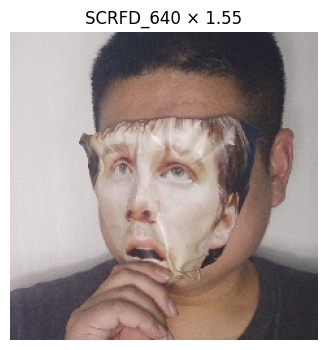

In [8]:

sample_key = str(train_keys[0])
img_path = os.path.join(DATA_ROOT, sample_key)
record = bbox_cache[sample_key]

print("KEY:", sample_key)
print("BBox source:", record["bbox_source"])
print("Status:", record["status"])
print("BBox xyxy:", np.round(record["bbox_xyxy"], 2).tolist())
print("Native min-face size:", round(float(record["face_min_side"]), 2), "px")
print("Crop factor:", record["crop_factor"])
print("Raw IoU to CelebA:", record.get("raw_iou_to_celeba"))
print("Center shift:", record.get("center_shift_norm"))

crop_rgb = read_cached_face_crop_rgb(
    img_path,
    record,
    bbox_jitter=False,
    strict=True,
)
print("Final crop (H,W):", crop_rgb.shape[:2])

plt.figure(figsize=(4, 4))
plt.imshow(crop_rgb)
plt.axis("off")
plt.title(f"{record['bbox_source']} × {record['crop_factor']:.2f}")
plt.show()



# Training + Validation calibration + safe resume

Checkpoint selection and PAD threshold calibration use **Validation only**.

```text
d = real_logit - logsumexp([physical_spoof_logit, digital_spoof_logit])
REAL iff d >= logit_threshold
```

Do not resume a MobileNetV3-Large checkpoint or a checkpoint produced with a
different split/cache/preprocessing fingerprint.


Saved run config: mnv3s_e1_preliminary_v5_3_edge_run_config.json
No compatible checkpoint -> training from ImageNet initialization
Max optimizer-step budget: 18,552 vs v4 reference 15,640 (1.19×; early stopping can reduce this).


Epoch 1/24 [Train]: 100%|██████████| 773/773 [07:32<00:00,  1.71it/s, acc3=0.8006, loss=0.6948]


⭐ New best: epoch=1, Val ACER=2.884%, APCER=3.137%, BPCER=2.631%, logit_thr=-0.570483, predictor_p=0.361125
Epoch 1: train_loss=0.6948, train_acc3=80.06% | val_loss=0.5003, val_acc3=89.71% | APCER=3.14%, BPCER=2.63%, ACER=2.88%, AUC=99.58% | logit_thr=-0.57048, predictor_p=0.36113 | grad_norm=0.807, no_improve=0/4


Epoch 2/24 [Train]: 100%|██████████| 773/773 [06:31<00:00,  1.98it/s, acc3=0.9111, loss=0.4718]


⭐ New best: epoch=2, Val ACER=1.159%, APCER=1.233%, BPCER=1.084%, logit_thr=-0.678323, predictor_p=0.336636
Epoch 2: train_loss=0.4718, train_acc3=91.11% | val_loss=0.4177, val_acc3=93.93% | APCER=1.23%, BPCER=1.08%, ACER=1.16%, AUC=99.91% | logit_thr=-0.67832, predictor_p=0.33664 | grad_norm=0.913, no_improve=0/4


...

Epoch 17: train_loss=0.3210, train_acc3=99.01% | val_loss=0.3325, val_acc3=97.98% | APCER=0.37%, BPCER=0.34%, ACER=0.35%, AUC=99.98% | logit_thr=-0.36632, predictor_p=0.40943 | grad_norm=0.684, no_improve=2/4


Epoch 18/24 [Train]: 100%|██████████| 773/773 [06:45<00:00,  1.91it/s, acc3=0.9906, loss=0.3201]


Epoch 18: train_loss=0.3201, train_acc3=99.06% | val_loss=0.3316, val_acc3=97.97% | APCER=0.44%, BPCER=0.24%, ACER=0.34%, AUC=99.98% | logit_thr=-0.63387, predictor_p=0.34663 | grad_norm=0.691, no_improve=3/4


Epoch 19/24 [Train]: 100%|██████████| 773/773 [06:34<00:00,  1.96it/s, acc3=0.9909, loss=0.3194]


⭐ New best: epoch=19, Val ACER=0.333%, APCER=0.345%, BPCER=0.321%, logit_thr=-0.465022, predictor_p=0.385795
Epoch 19: train_loss=0.3194, train_acc3=99.09% | val_loss=0.3317, val_acc3=97.94% | APCER=0.35%, BPCER=0.32%, ACER=0.33%, AUC=99.98% | logit_thr=-0.46502, predictor_p=0.38580 | grad_norm=0.673, no_improve=4/4
⏹️ Early stopping at epoch 19: no Validation ACER improvement > 0.000100 for 4 epochs.
Saved history: mnv3s_e1_preliminary_v5_3_edge_training_history.json


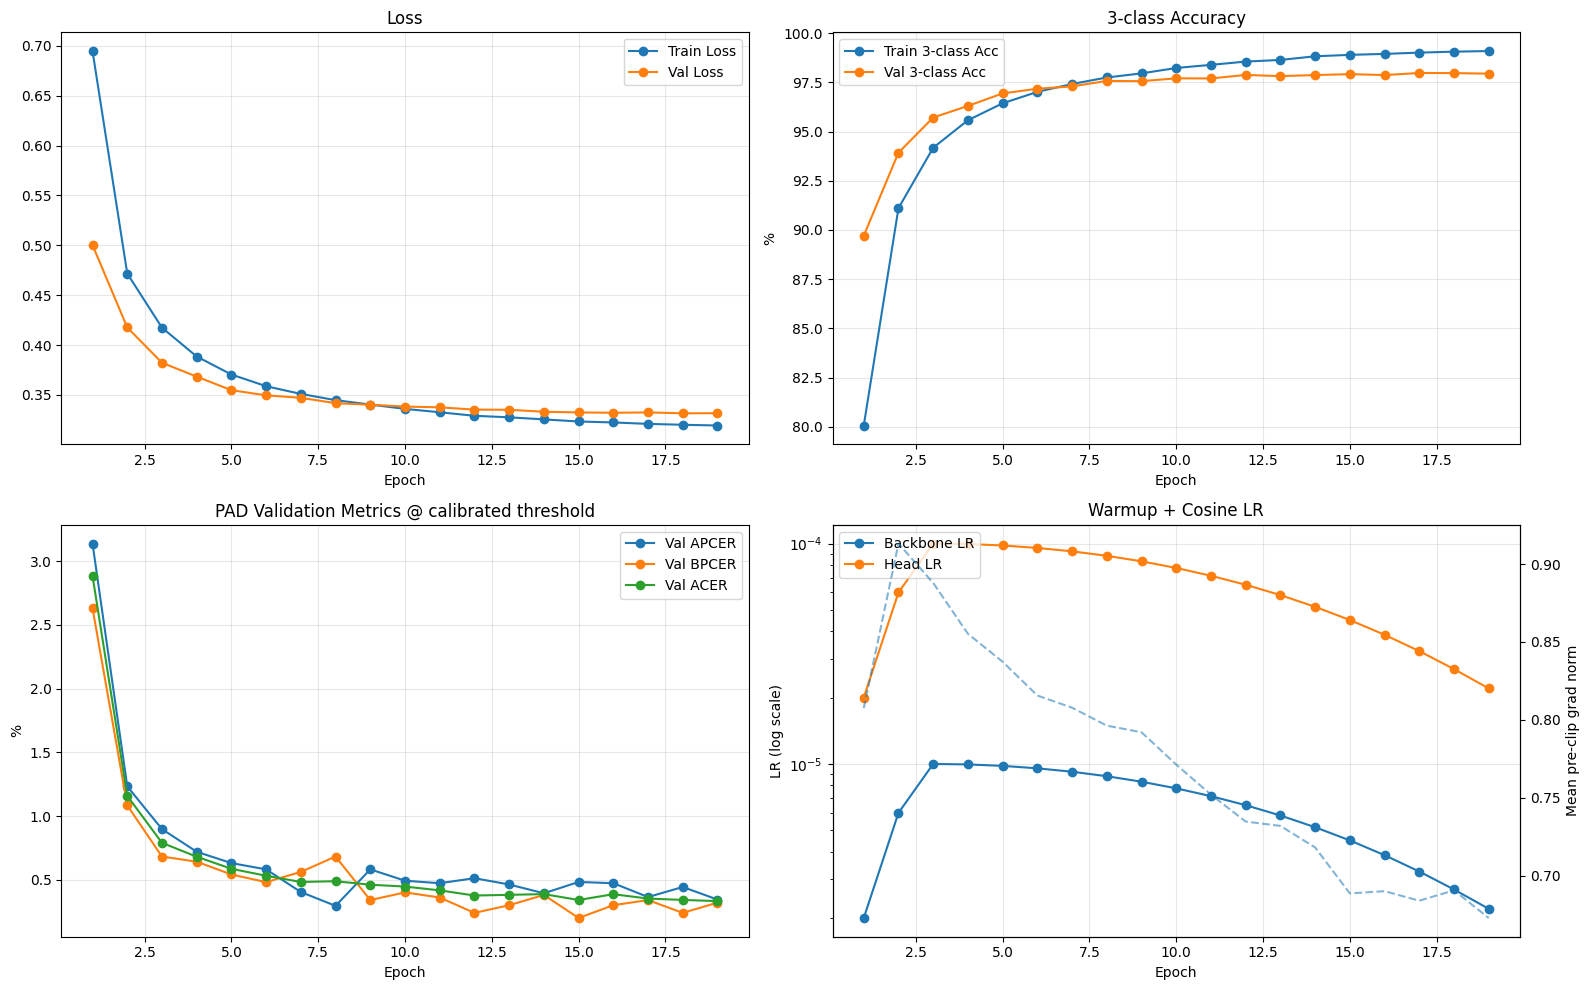

Best validation ACER: 0.333% at epoch 19
Locked logit threshold: -0.4650222063064575
AntiSpoofPredictor probability threshold: 0.38579510
Best model: mnv3s_e1_preliminary_v5_3_edge_best.pth
Metadata : mnv3s_e1_preliminary_v5_3_edge_best_meta.json


In [9]:
# Cell 5: Training Loop — ACER checkpoint + production-compatible score/calibration + safe resume
RUN_NAME = f"mnv3s_e1_{RUN_MODE}_v5_3_edge"
CHECKPOINT_PATH = f"{RUN_NAME}_checkpoint_last.pth"
BEST_MODEL_PATH = f"{RUN_NAME}_best.pth"
BEST_META_PATH = f"{RUN_NAME}_best_meta.json"
HISTORY_PATH = f"{RUN_NAME}_training_history.json"
RUN_CONFIG_PATH = f"{RUN_NAME}_run_config.json"

# IMPORTANT: point only to a checkpoint produced by THIS protocol version.
CHECKPOINT_INPUT_PATH = ""  # e.g. "/kaggle/input/<previous-output>/checkpoint_last.pth"


def logits_to_pad_score(outputs):
    """
    Match AntiSpoofPredictor.process_with_logits():
        pad_score = real_logit - logsumexp(all_spoof_logits)
    This is exactly equivalent to logit(P_real / (1-P_real)) for a 3-class softmax model.
    """
    real_logit = outputs[:, 0]
    spoof_logsumexp = torch.logsumexp(outputs[:, 1:], dim=1)
    return real_logit - spoof_logsumexp


PREDICTOR_PROB_EPS = 1e-6
PREDICTOR_MIN_LOGIT_THRESHOLD = math.log(PREDICTOR_PROB_EPS / (1.0 - PREDICTOR_PROB_EPS))
PREDICTOR_MAX_LOGIT_THRESHOLD = -PREDICTOR_MIN_LOGIT_THRESHOLD


def probability_from_logit_threshold(t):
    """Stable sigmoid: converts calibrated pad-score threshold to AntiSpoofPredictor(threshold=p)."""
    t = float(t)
    if t >= 0:
        z = math.exp(-t)
        return 1.0 / (1.0 + z)
    z = math.exp(t)
    return z / (1.0 + z)


def calibrate_threshold_min_acer(pad_scores, binary_labels):
    """
    Score convention: d = real_logit - logsumexp(spoof_logits).
    Predict Real when d >= threshold, Spoof when d < threshold.
    Threshold is chosen on Validation ONLY by minimum ACER.
    Tie-break: lower APCER, then lower BPCER.
    """
    d = np.asarray(pad_scores, dtype=np.float64)
    y = np.asarray(binary_labels, dtype=np.int64)
    real_scores = np.sort(d[y == 0])
    spoof_scores = np.sort(d[y == 1])
    if len(real_scores) == 0 or len(spoof_scores) == 0:
        raise ValueError("Validation set must contain both Real and Spoof samples")
    if not np.all(np.isfinite(d)):
        raise ValueError("Non-finite PAD scores detected during validation")

    unique_scores = np.unique(d)
    thresholds = np.concatenate((
        [np.nextafter(unique_scores[0], -np.inf)],
        unique_scores,
        [np.nextafter(unique_scores[-1], np.inf)],
        [PREDICTOR_MIN_LOGIT_THRESHOLD, PREDICTOR_MAX_LOGIT_THRESHOLD],
    ))
    # Predictor clamps probability threshold to [1e-6, 1-1e-6]. Keep calibration
    # inside the exactly representable logit range so deployment decisions are identical.
    thresholds = np.unique(np.clip(
        thresholds, PREDICTOR_MIN_LOGIT_THRESHOLD, PREDICTOR_MAX_LOGIT_THRESHOLD
    ))

    # BPCER = Real -> Spoof = P(d < t | real)
    bpcer = np.searchsorted(real_scores, thresholds, side="left") / len(real_scores)
    # APCER = Spoof -> Real = P(d >= t | spoof)
    apcer = 1.0 - np.searchsorted(spoof_scores, thresholds, side="left") / len(spoof_scores)
    acer = 0.5 * (apcer + bpcer)

    # np.lexsort uses the LAST key as primary: ACER -> APCER -> BPCER.
    best_idx = np.lexsort((bpcer, apcer, acer))[0]
    logit_threshold = float(thresholds[best_idx])
    return {
        "logit_threshold": logit_threshold,
        "probability_threshold": probability_from_logit_threshold(logit_threshold),
        "APCER": float(apcer[best_idx]),
        "BPCER": float(bpcer[best_idx]),
        "ACER": float(acer[best_idx]),
    }


def metrics_from_scores(binary_labels, pad_scores, logit_threshold):
    y_true = np.asarray(binary_labels, dtype=np.int64)
    d = np.asarray(pad_scores, dtype=np.float64)
    y_pred = (d < logit_threshold).astype(np.int64)  # 0 Real, 1 Spoof
    spoof_score = -d  # larger => more spoof-like

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()

    # Positive class = Spoof.
    # APCER: attack (Spoof) accepted as Real => FN / all Spoof.
    apcer = FN / (FN + TP) if (FN + TP) else 0.0
    # BPCER: bona fide (Real) rejected as Spoof => FP / all Real.
    bpcer = FP / (TN + FP) if (TN + FP) else 0.0
    acer = 0.5 * (apcer + bpcer)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, spoof_score) if len(np.unique(y_true)) == 2 else float("nan")

    return {
        "Accuracy": float(acc),
        "APCER": float(apcer),
        "BPCER": float(bpcer),
        "ACER": float(acer),
        "AUC": float(auc),
        "confusion_matrix": cm.tolist(),
    }


def collect_validation(model, loader):
    model.eval()
    total_loss = 0.0
    total = 0
    correct_3class = 0
    all_binary_labels = []
    all_pad_scores = []

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            bs = labels.size(0)
            total_loss += loss.item() * bs
            total += bs
            correct_3class += (outputs.argmax(dim=1) == labels).sum().item()

            d = logits_to_pad_score(outputs).detach().cpu().numpy()
            binary = (labels > 0).long().detach().cpu().numpy()
            all_pad_scores.append(d)
            all_binary_labels.append(binary)

    if total == 0:
        raise RuntimeError("Validation loader is empty")

    return {
        "loss": total_loss / total,
        "acc_3class": correct_3class / total,
        "pad_scores": np.concatenate(all_pad_scores),
        "binary_labels": np.concatenate(all_binary_labels),
    }


def cpu_state_dict(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def save_best_artifacts(best_state, best_epoch, best_val_metrics, best_logit_threshold):
    torch.save(best_state, BEST_MODEL_PATH)
    probability_threshold = probability_from_logit_threshold(best_logit_threshold)
    meta = {
        "protocol_version": PROTOCOL_VERSION,
        "backbone_name": BACKBONE_NAME,
        "backbone_weights": BACKBONE_WEIGHTS,
        "backbone_feature_dim": BACKBONE_FEATURE_DIM,
        "model_parameter_count": MODEL_PARAMETER_COUNT,
        "best_epoch": int(best_epoch),
        "calibrated_logit_threshold": float(best_logit_threshold),
        "calibrated_probability_threshold": float(probability_threshold),
        "validation_metrics_percent": {
            k: (100.0 * float(v) if k in {"Accuracy", "APCER", "BPCER", "ACER", "AUC"} else v)
            for k, v in best_val_metrics.items()
            if k != "confusion_matrix"
        },
        "confusion_matrix": best_val_metrics["confusion_matrix"],
        "score_definition": "pad_score = real_logit - logsumexp([physical_spoof_logit, digital_spoof_logit]); Real iff pad_score >= logit_threshold",
        "predictor_contract": {
            "threshold_argument": float(probability_threshold),
            "apply_gamma": False,
            "color_order": "RGB",
            "model_img_size": INPUT_SIZE,
            "bbox_expansion_factor": SCRFD_BBOX_EXPANSION_FACTOR,
            "mean": CELEBA_MEAN,
            "std": CELEBA_STD,
        },
        "gamma_policy": "Research baseline is calibrated without gamma. If deployment uses apply_gamma=True, recalibrate a separate threshold on Validation under gamma preprocessing.",
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples_configured": len(test_dataset),
        "train_subjects": len(train_split_subjects),
        "val_subjects": len(val_split_subjects),
        "sample_seed": SAMPLE_SEED,
        "input_size": INPUT_SIZE,
        "bbox_expansion_factor": SCRFD_BBOX_EXPANSION_FACTOR,
        "normalization_mean": CELEBA_MEAN,
        "normalization_std": CELEBA_STD,
        "preprocess_policy": PREPROCESS_POLICY,
        "preprocess_stats": PREPROCESS_STATS,
        "bbox_cache_file": SCRFD_CACHE_PATH,
        "bbox_cache_selected_fingerprint": BBOX_CACHE_FINGERPRINT,
        "split_fingerprints": SPLIT_FINGERPRINTS,
        "split_manifest": SPLIT_MANIFEST_PATH,
        "evaluation_scope": (
            "PAD model evaluation on detector-conditioned crops; "
            "detector coverage is reported separately."
        ),
    }
    with open(BEST_META_PATH, "w") as f:
        json.dump(meta, f, indent=2)


start_epoch = 0
best_val_acer = float("inf")
best_logit_threshold = None
best_epoch = -1
best_model_state = None
best_val_metrics = None
epochs_without_improvement = 0

RUN_CONFIG = {
    "protocol_version": PROTOCOL_VERSION,
    "backbone_name": BACKBONE_NAME,
    "backbone_weights": BACKBONE_WEIGHTS,
    "backbone_feature_dim": BACKBONE_FEATURE_DIM,
    "model_parameter_count": MODEL_PARAMETER_COUNT,
    "epochs": EPOCHS,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "scheduler": "WarmupCosineLambdaLR",
    "warmup_epochs": WARMUP_EPOCHS,
    "warmup_start_factor": WARMUP_START_FACTOR,
    "min_lr_factor": MIN_LR_FACTOR,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,
    "early_stop_min_epochs": EARLY_STOP_MIN_EPOCHS,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "strict_determinism": STRICT_DETERMINISM,
    "cudnn_benchmark": bool(torch.backends.cudnn.benchmark),
    "run_mode": RUN_MODE,
    "batch_size": BATCH_SIZE,
    "input_size": INPUT_SIZE,
    "bbox_expansion_factor": SCRFD_BBOX_EXPANSION_FACTOR,
    "normalization_mean": CELEBA_MEAN,
    "normalization_std": CELEBA_STD,
    "preprocess_policy": PREPROCESS_POLICY,
    "preprocess_stats": PREPROCESS_STATS,
    "bbox_cache_file": SCRFD_CACHE_PATH,
    "bbox_cache_selected_fingerprint": BBOX_CACHE_FINGERPRINT,
    "num_classes": NUM_CLASSES,
    "spatial_dim": SPATIAL_DIM,
    "hidden_dim": HIDDEN_DIM,
    "dropout_rate": DROPOUT_RATE,
    "label_smoothing": LABEL_SMOOTHING,
    "class_weights": [1.0, 1.0, 1.0],
    "train_sample_size": TRAIN_SAMPLE_SIZE,
    "val_target_size": VAL_SAMPLE_SIZE,
    "val_actual_size": len(val_dataset),
    "test_sample_size": TEST_SAMPLE_SIZE,
    "sample_seed": SAMPLE_SEED,
    "research_apply_gamma": False,
    "augmentation": {
        "horizontal_flip_p": 0.5,
        "brightness_limit": 0.10,
        "contrast_limit": 0.10,
        "appearance_p": 0.30,
        "bbox_jitter_p": BBOX_JITTER_P,
        "bbox_scale_jitter": list(BBOX_JITTER_SCALE),
        "bbox_translate_fraction": BBOX_JITTER_TRANSLATE,
        "affine_rotation": False,
    },
    "score_definition": "real_minus_logsumexp_spoof",
    "split_fingerprints": SPLIT_FINGERPRINTS,
    "split_manifest": SPLIT_MANIFEST_PATH,
}
with open(RUN_CONFIG_PATH, "w") as f:
    json.dump(RUN_CONFIG, f, indent=2)
print(f"Saved run config: {RUN_CONFIG_PATH}")

history = {
    "train_loss": [], "train_acc_3class": [],
    "val_loss": [], "val_acc_3class": [],
    "val_apcer": [], "val_bpcer": [], "val_acer": [], "val_auc": [],
    "val_logit_threshold": [], "val_probability_threshold": [],
    "lr_backbone": [], "lr_head": [], "grad_norm": [],
}

resume_source = None
if os.path.exists(CHECKPOINT_PATH):
    resume_source = CHECKPOINT_PATH
elif CHECKPOINT_INPUT_PATH and os.path.exists(CHECKPOINT_INPUT_PATH):
    shutil.copy(CHECKPOINT_INPUT_PATH, CHECKPOINT_PATH)
    resume_source = CHECKPOINT_PATH

if resume_source is not None:
    # Full research checkpoints contain optimizer/RNG Python objects -> weights_only=False is intentional.
    ckpt = safe_torch_load(resume_source, map_location=device, weights_only=False)
    ckpt_protocol = ckpt.get("protocol_version")
    if ckpt_protocol != PROTOCOL_VERSION:
        raise RuntimeError(
            f"Refusing incompatible checkpoint: protocol={ckpt_protocol!r}, expected={PROTOCOL_VERSION!r}. "
            "Do NOT resume from a different backbone/protocol/preprocessing run."
        )

    ckpt_config = ckpt.get("config")
    if ckpt_config != RUN_CONFIG:
        raise RuntimeError(
            "Refusing checkpoint with a different run configuration/split.\n"
            f"checkpoint config={ckpt_config}\ncurrent config={RUN_CONFIG}"
        )

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    if "scaler_state" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state"])

    start_epoch = int(ckpt["epoch"]) + 1
    best_val_acer = float(ckpt["best_val_acer"])
    best_logit_threshold = ckpt.get("best_logit_threshold")
    best_epoch = int(ckpt.get("best_epoch", -1))
    best_model_state = ckpt.get("best_model_state")
    best_val_metrics = ckpt.get("best_val_metrics")
    epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
    history = ckpt["history"]

    if "loader_generator_state" in ckpt:
        loader_generator.set_state(ckpt["loader_generator_state"])
    if "torch_rng_state" in ckpt:
        torch.set_rng_state(ckpt["torch_rng_state"])
    if torch.cuda.is_available() and ckpt.get("cuda_rng_state_all") is not None:
        torch.cuda.set_rng_state_all(ckpt["cuda_rng_state_all"])
    if "numpy_rng_state" in ckpt:
        np.random.set_state(ckpt["numpy_rng_state"])
    if "python_rng_state" in ckpt:
        random.setstate(ckpt["python_rng_state"])

    # Re-create best artifacts in a new Kaggle session if only checkpoint_last was mounted.
    if best_model_state is not None and not os.path.exists(BEST_MODEL_PATH):
        torch.save(best_model_state, BEST_MODEL_PATH)
    if (best_model_state is not None and best_val_metrics is not None and best_logit_threshold is not None
            and not os.path.exists(BEST_META_PATH)):
        save_best_artifacts(best_model_state, best_epoch, best_val_metrics, best_logit_threshold)

    print(f"✅ Resume protocol v5.3 from epoch {start_epoch + 1}/{EPOCHS}; "
          f"best val ACER={best_val_acer*100:.3f}% @ epoch {best_epoch+1}")
else:
    print("No compatible checkpoint -> training from ImageNet initialization")

if start_epoch >= EPOCHS:
    print(f"🎉 Training already completed {EPOCHS} epochs.")

# Time-budget sanity check relative to v4 preliminary (100K, batch 128, 20 epochs).
if RUN_MODE == "preliminary":
    v4_ref_steps = math.ceil(100_000 / 128) * 20
    current_max_steps = len(train_loader) * EPOCHS
    print(f"Max optimizer-step budget: {current_max_steps:,} vs v4 reference {v4_ref_steps:,} "
          f"({current_max_steps / v4_ref_steps:.2f}×; early stopping can reduce this).")

for epoch in range(start_epoch, EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    grad_norm_sum = 0.0
    grad_norm_steps = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if hasattr(torch, "amp"):
            autocast_ctx = torch.amp.autocast(device_type=device.type, enabled=amp_enabled)
        else:
            autocast_ctx = torch.cuda.amp.autocast(enabled=amp_enabled)

        with autocast_ctx:
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        if torch.isfinite(grad_norm):
            grad_norm_sum += float(grad_norm.detach().cpu())
            grad_norm_steps += 1
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total += bs
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        pbar.set_postfix(loss=f"{running_loss/total:.4f}", acc3=f"{correct/total:.4f}")

    train_loss = running_loss / total
    train_acc = correct / total
    mean_grad_norm = grad_norm_sum / max(1, grad_norm_steps)

    # Validation is the ONLY source for checkpoint selection + threshold calibration.
    val = collect_validation(model, val_loader)
    cal = calibrate_threshold_min_acer(val["pad_scores"], val["binary_labels"])
    val_metrics = metrics_from_scores(
        val["binary_labels"], val["pad_scores"], cal["logit_threshold"]
    )

    history["train_loss"].append(train_loss)
    history["train_acc_3class"].append(train_acc)
    history["val_loss"].append(val["loss"])
    history["val_acc_3class"].append(val["acc_3class"])
    history["val_apcer"].append(val_metrics["APCER"])
    history["val_bpcer"].append(val_metrics["BPCER"])
    history["val_acer"].append(val_metrics["ACER"])
    history["val_auc"].append(val_metrics["AUC"])
    history["val_logit_threshold"].append(cal["logit_threshold"])
    history["val_probability_threshold"].append(cal["probability_threshold"])
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])
    history["grad_norm"].append(mean_grad_norm)

    # Select checkpoint by Validation ACER. Tie-break by lower Validation APCER.
    current_acer = val_metrics["ACER"]
    current_apcer = val_metrics["APCER"]
    best_before_epoch = best_val_acer
    previous_best_apcer = float("inf")
    if best_epoch >= 0 and best_epoch < len(history["val_apcer"]):
        previous_best_apcer = history["val_apcer"][best_epoch]

    is_better = (
        current_acer < best_val_acer - 1e-12
        or (abs(current_acer - best_val_acer) <= 1e-12 and current_apcer < previous_best_apcer)
    )

    if is_better:
        best_val_acer = current_acer
        best_logit_threshold = float(cal["logit_threshold"])
        best_epoch = epoch
        best_model_state = cpu_state_dict(model)
        best_val_metrics = copy.deepcopy(val_metrics)
        save_best_artifacts(best_model_state, best_epoch, best_val_metrics, best_logit_threshold)
        print(
            f"⭐ New best: epoch={epoch+1}, Val ACER={current_acer*100:.3f}%, "
            f"APCER={current_apcer*100:.3f}%, BPCER={val_metrics['BPCER']*100:.3f}%, "
            f"logit_thr={best_logit_threshold:.6f}, "
            f"predictor_p={probability_from_logit_threshold(best_logit_threshold):.6f}"
        )

    # Early stopping requires a meaningful ACER improvement, not numerical noise.
    if current_acer < best_before_epoch - EARLY_STOP_MIN_DELTA:
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    scheduler.step()

    checkpoint = {
        "protocol_version": PROTOCOL_VERSION,
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_acer": best_val_acer,
        "best_logit_threshold": best_logit_threshold,
        "best_epoch": best_epoch,
        "best_model_state": best_model_state,
        "best_val_metrics": best_val_metrics,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "loader_generator_state": loader_generator.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "numpy_rng_state": np.random.get_state(),
        "python_rng_state": random.getstate(),
        "config": RUN_CONFIG,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

    print(
        f"Epoch {epoch+1}: train_loss={train_loss:.4f}, train_acc3={train_acc*100:.2f}% | "
        f"val_loss={val['loss']:.4f}, val_acc3={val['acc_3class']*100:.2f}% | "
        f"APCER={val_metrics['APCER']*100:.2f}%, BPCER={val_metrics['BPCER']*100:.2f}%, "
        f"ACER={val_metrics['ACER']*100:.2f}%, AUC={val_metrics['AUC']*100:.2f}% | "
        f"logit_thr={cal['logit_threshold']:.5f}, predictor_p={cal['probability_threshold']:.5f} | "
        f"grad_norm={mean_grad_norm:.3f}, no_improve={epochs_without_improvement}/{EARLY_STOP_PATIENCE}"
    )

    if (epoch + 1 >= EARLY_STOP_MIN_EPOCHS
            and epochs_without_improvement >= EARLY_STOP_PATIENCE):
        print(f"⏹️ Early stopping at epoch {epoch+1}: no Validation ACER improvement > "
              f"{EARLY_STOP_MIN_DELTA:.6f} for {EARLY_STOP_PATIENCE} epochs.")
        break

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Saved history: {HISTORY_PATH}")

# Plot training history.
epoch_axis = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(epoch_axis, history["train_loss"], label="Train Loss", marker='o')
axes[0,0].plot(epoch_axis, history["val_loss"], label="Val Loss", marker='o')
axes[0,0].set_title("Loss")
axes[0,0].set_xlabel("Epoch")
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(epoch_axis, np.array(history["train_acc_3class"]) * 100, label="Train 3-class Acc", marker='o')
axes[0,1].plot(epoch_axis, np.array(history["val_acc_3class"]) * 100, label="Val 3-class Acc", marker='o')
axes[0,1].set_title("3-class Accuracy")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("%")
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(epoch_axis, np.array(history["val_apcer"]) * 100, label="Val APCER", marker='o')
axes[1,0].plot(epoch_axis, np.array(history["val_bpcer"]) * 100, label="Val BPCER", marker='o')
axes[1,0].plot(epoch_axis, np.array(history["val_acer"]) * 100, label="Val ACER", marker='o')
axes[1,0].set_title("PAD Validation Metrics @ calibrated threshold")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("%")
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(epoch_axis, history["lr_backbone"], label="Backbone LR", marker='o')
axes[1,1].plot(epoch_axis, history["lr_head"], label="Head LR", marker='o')
axes[1,1].set_yscale("log")
axes[1,1].set_title("Warmup + Cosine LR")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("LR (log scale)")
axes[1,1].legend(loc="upper left"); axes[1,1].grid(alpha=0.3)
ax2 = axes[1,1].twinx()
ax2.plot(epoch_axis, history["grad_norm"], linestyle='--', alpha=0.55, label="Grad norm")
ax2.set_ylabel("Mean pre-clip grad norm")

plt.tight_layout()
plt.savefig(f"{RUN_NAME}_training_history.png", dpi=160)
plt.show()

print(f"Best validation ACER: {best_val_acer*100:.3f}% at epoch {best_epoch+1}")
print(f"Locked logit threshold: {best_logit_threshold}")
print(f"AntiSpoofPredictor probability threshold: {probability_from_logit_threshold(best_logit_threshold):.8f}")
print(f"Best model: {BEST_MODEL_PATH}")
print(f"Metadata : {BEST_META_PATH}")



# Held-out Evaluation — intentionally gated

Held-out Test stays disabled while developing v5.3.

After model/preprocessing decisions are frozen:

- lock checkpoint using Validation ACER;
- lock threshold using Validation only;
- keep small faces and detector failures in Test;
- report detector coverage / bbox source separately;
- do not tune from Test.

This is PAD-model evaluation on detector-conditioned crops with annotation fallback,
not a pure end-to-end detector metric.


In [10]:
# Cell 6: Held-out in-domain test + optional external sanity check

def collect_scores(model, loader, name="Dataset"):
    model.eval()
    all_binary_labels = []
    all_pad_scores = []

    with torch.inference_mode():
        for images, labels in tqdm(loader, desc=f"Evaluating {name}"):
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            d = logits_to_pad_score(outputs).detach().cpu().numpy()
            binary = (labels > 0).long().numpy()
            all_pad_scores.append(d)
            all_binary_labels.append(binary)

    if not all_pad_scores:
        raise RuntimeError(f"{name} loader is empty")
    return np.concatenate(all_binary_labels), np.concatenate(all_pad_scores)


def evaluate_loader(model, loader, logit_threshold, name="Dataset"):
    y_true, d = collect_scores(model, loader, name=name)
    result = metrics_from_scores(y_true, d, logit_threshold)
    result["LogitThreshold"] = float(logit_threshold)
    result["PredictorProbabilityThreshold"] = probability_from_logit_threshold(logit_threshold)
    return result



RUN_HELDOUT_TEST = False
RUN_EXTERNAL_SANITY = False

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Missing best model: {BEST_MODEL_PATH}")
if not os.path.exists(BEST_META_PATH):
    raise FileNotFoundError(f"Missing best metadata/threshold: {BEST_META_PATH}")

model.load_state_dict(safe_torch_load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
with open(BEST_META_PATH, 'r') as f:
    best_meta = json.load(f)

if best_meta.get("protocol_version") != PROTOCOL_VERSION:
    raise RuntimeError("Best metadata protocol does not match current notebook protocol")

locked_logit_threshold = float(best_meta["calibrated_logit_threshold"])
locked_probability_threshold = float(best_meta["calibrated_probability_threshold"])
print(f"Locked Validation logit threshold: {locked_logit_threshold:.6f}")
print(f"AntiSpoofPredictor(threshold=...): {locked_probability_threshold:.8f}")
print("Research inference profile: apply_gamma=False, color_order=RGB")
print(f"Best epoch: {best_meta['best_epoch'] + 1}")

if RUN_HELDOUT_TEST:
    test_results = evaluate_loader(
        model, test_loader,
        logit_threshold=locked_logit_threshold,
        name="CelebA-Spoof Held-out Test",
    )
    print("\nCelebA-Spoof Held-out Test")
    print(f"  Detector coverage: {PREPROCESS_STATS['test_detector_coverage']*100:.3f}%")
    print("  BBox sources      :", PREPROCESS_STATS["test_source_counts"])
    for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]:
        print(f"  {k:8s}: {test_results[k]*100:.3f}%")
    print("  Logit threshold:", test_results["LogitThreshold"])
    print("  Predictor p     :", test_results["PredictorProbabilityThreshold"])
    print("  CM [[TN,FP],[FN,TP]]:", test_results["confusion_matrix"])

    with open(f"{RUN_NAME}_heldout_test_results.json", "w") as f:
        json.dump({
            "protocol_version": PROTOCOL_VERSION,
            "run_mode": RUN_MODE,
            "test_size": len(test_dataset),
            "is_quick_test": TEST_SAMPLE_SIZE is not None,
            "research_apply_gamma": False,
            "preprocess_policy": PREPROCESS_POLICY,
            "test_detector_coverage": PREPROCESS_STATS["test_detector_coverage"],
            "test_bbox_source_counts": PREPROCESS_STATS["test_source_counts"],
            "backbone_name": BACKBONE_NAME,
            "model_parameter_count": MODEL_PARAMETER_COUNT,
            "bbox_cache_selected_fingerprint": BBOX_CACHE_FINGERPRINT,
            "evaluation_scope": (
                "PAD metric on detector-conditioned crops with CelebA fallback; "
                "not a pure end-to-end detector failure metric."
            ),
            "locked_validation_logit_threshold": locked_logit_threshold,
            "predictor_probability_threshold": locked_probability_threshold,
            "metrics_percent": {k: test_results[k] * 100 for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]},
            "confusion_matrix": test_results["confusion_matrix"],
        }, f, indent=2)
else:
    test_results = None
    print("\n🔒 Held-out Test is disabled by default. Freeze the protocol first, then set RUN_HELDOUT_TEST=True.")

external_results = None
if RUN_EXTERNAL_SANITY:
    if "lcc_loader" in globals() and lcc_loader is not None:
        external_results = evaluate_loader(
            model, lcc_loader,
            logit_threshold=locked_logit_threshold,
            name="LCC-FASD External Sanity Check",
        )
        print("\nLCC-FASD External Sanity Check (same locked threshold; NO tuning)")
        for k in ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]:
            print(f"  {k:8s}: {external_results[k]*100:.3f}%")
    else:
        print("\n⚠️ RUN_EXTERNAL_SANITY=True but lcc_loader is not defined; skipping.")
else:
    print("ℹ️ External sanity evaluation disabled.")

result_sets = []
if test_results is not None:
    result_sets.append(("CelebA Held-out", test_results))
if external_results is not None:
    result_sets.append(("LCC-FASD", external_results))

if result_sets:
    metrics = ["Accuracy", "APCER", "BPCER", "ACER", "AUC"]
    x = np.arange(len(metrics))
    width = 0.8 / len(result_sets)
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (label, results) in enumerate(result_sets):
        vals = [results[m] * 100 for m in metrics]
        offset = (i - (len(result_sets)-1)/2) * width
        bars = ax.bar(x + offset, vals, width, label=label)
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.1f}", (bar.get_x()+bar.get_width()/2, h),
                        xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
    ax.set_ylabel("%")
    ax.set_title("PAD Evaluation @ Locked Validation Threshold (No-Gamma Research Profile)")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RUN_NAME}_heldout_evaluation.png", dpi=160)
    plt.show()


Locked Validation logit threshold: -0.465022
AntiSpoofPredictor(threshold=...): 0.38579510
Research inference profile: apply_gamma=False, color_order=RGB
Best epoch: 19

🔒 Held-out Test is disabled by default. Freeze the protocol first, then set RUN_HELDOUT_TEST=True.
ℹ️ External sanity evaluation disabled.



# Export FP32 ONNX + parity + edge artifact summary

Required runtime contract:

```text
backbone = MobileNetV3-Small
detector = SCRFD-500M
crop factor = 1.55×
input = 224×224 RGB
gamma = OFF
threshold = calibrated from THIS v5.3 Validation split
```

The notebook records FP32 ONNX size and a host-CPU batch-1 ORT latency diagnostic.
That latency is not a Raspberry Pi benchmark.

Quantization remains a separate deployment experiment after E1 is frozen.


In [11]:
# Cell 7: Export FP32 ONNX + parity test + runtime config
if not ONNX_AVAILABLE:
    raise RuntimeError("onnx/onnxruntime unavailable. Install them before export.")
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"Missing best clean checkpoint: {BEST_MODEL_PATH}")
if not os.path.exists(BEST_META_PATH):
    raise FileNotFoundError(f"Missing best metadata: {BEST_META_PATH}")

model.load_state_dict(safe_torch_load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
with open(BEST_META_PATH, 'r') as f:
    best_meta = json.load(f)

onnx_filename = f"{RUN_NAME}_best.onnx"
dummy_input = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE, device=device)

with torch.no_grad():
    torch_dummy_output = model(dummy_input).detach().cpu().numpy()

torch.onnx.export(
    model,
    dummy_input,
    onnx_filename,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    },
)

onnx_model = onnx.load(onnx_filename)
onnx.checker.check_model(onnx_model)

# ORT parity on CPU to ensure exported graph matches PyTorch numerically.
session = ort.InferenceSession(onnx_filename, providers=["CPUExecutionProvider"])
ort_out = session.run(None, {session.get_inputs()[0].name: dummy_input.detach().cpu().numpy()})[0]
max_abs_diff = float(np.max(np.abs(torch_dummy_output - ort_out)))

print(f"✅ Exported FP32 ONNX: {onnx_filename}")
print(f"PyTorch/ONNX max |Δlogit| = {max_abs_diff:.8f}")
assert max_abs_diff < 1e-4, f"ONNX parity check failed: max_abs_diff={max_abs_diff}"

# Dynamic batch dimension.
batch4 = torch.randn(4, 3, INPUT_SIZE, INPUT_SIZE, device=device)
with torch.no_grad():
    pt4 = model(batch4).detach().cpu().numpy()
ort4 = session.run(None, {session.get_inputs()[0].name: batch4.detach().cpu().numpy()})[0]
batch4_diff = float(np.max(np.abs(pt4 - ort4)))
print(f"Dynamic batch=4 parity max |Δlogit| = {batch4_diff:.8f}")
assert batch4_diff < 1e-4

onnx_size_mb = os.path.getsize(onnx_filename) / (1024 * 1024)
print(f"FP32 ONNX size: {onnx_size_mb:.2f} MiB")

# Host CPU diagnostic only; NOT a Raspberry Pi performance claim.
cpu_benchmark_input = np.random.randn(
    1, 3, INPUT_SIZE, INPUT_SIZE
).astype(np.float32)
cpu_input_name = session.get_inputs()[0].name

for _ in range(20):
    session.run(None, {cpu_input_name: cpu_benchmark_input})

cpu_times_ms = []
for _ in range(100):
    t0 = time.perf_counter()
    session.run(None, {cpu_input_name: cpu_benchmark_input})
    cpu_times_ms.append((time.perf_counter() - t0) * 1000.0)

cpu_latency = {
    "mean_ms": float(np.mean(cpu_times_ms)),
    "median_ms": float(np.median(cpu_times_ms)),
    "p90_ms": float(np.percentile(cpu_times_ms, 90)),
}
print("Host CPU ORT batch-1 latency:", cpu_latency)

# Deployment/research runtime contract. Predictor's `threshold` argument is a probability.
runtime_config = {
    "protocol_version": PROTOCOL_VERSION,
    "backbone_name": BACKBONE_NAME,
    "backbone_weights": BACKBONE_WEIGHTS,
    "backbone_feature_dim": BACKBONE_FEATURE_DIM,
    "model_parameter_count": MODEL_PARAMETER_COUNT,
    "model_file": onnx_filename,
    "model_img_size": INPUT_SIZE,
    "bbox_expansion_factor": SCRFD_BBOX_EXPANSION_FACTOR,
    "color_order": "RGB",
    "mean": CELEBA_MEAN,
    "std": CELEBA_STD,
    "apply_gamma": False,
    "onnx_fp32_size_mb": float(onnx_size_mb),
    "host_cpu_ort_batch1_latency_ms": cpu_latency,
    "benchmark_note": "Host CPU diagnostic only; benchmark Raspberry Pi separately.",
    "bbox_detector": "SCRFD-500M",
    "train_min_face_px": TRAIN_MIN_FACE_SIZE,
    "preprocess_policy": PREPROCESS_POLICY,
    "bbox_cache_selected_fingerprint": BBOX_CACHE_FINGERPRINT,
    "score_definition": "pad_score = real_logit - logsumexp(all_spoof_logits)",
    "calibrated_logit_threshold": float(best_meta["calibrated_logit_threshold"]),
    "predictor_threshold_probability": float(best_meta["calibrated_probability_threshold"]),
    "predictor_example": "AntiSpoofPredictor(model_path='<exported_onnx_path>', threshold=<predictor_threshold_probability>, model_img_size=224, bbox_expansion_factor=1.55, mean=CELEBA_MEAN, std=CELEBA_STD, apply_gamma=False, color_order='RGB')",
    "gamma_note": "If apply_gamma=True is used in production, recalibrate a separate threshold on Validation using the gamma inference preprocessing. Do not reuse this no-gamma threshold.",
}
runtime_config_path = f"{RUN_NAME}_runtime_config.json"
with open(runtime_config_path, "w") as f:
    json.dump(runtime_config, f, indent=2)

print(f"✅ Saved runtime contract: {runtime_config_path}")
print(f"AntiSpoofPredictor threshold probability = {runtime_config['predictor_threshold_probability']:.8f}")
print("Research runtime requires apply_gamma=False")


ModuleNotFoundError: No module named 'onnxscript'